<a href="https://colab.research.google.com/github/ThonggKunn/Metro_traffic_ml/blob/main/metro_traffic_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ĐỒ ÁN HỌC MÁY: DỰ ĐOÁN LƯU LƯỢNG GIAO THÔNG
## Metro Interstate Traffic Volume — Bài toán Hồi Quy


#
**Dataset:** Metro Interstate Traffic Volume  
**Target:** `traffic_volume` (Lưu lượng xe/giờ)


---
# PHẦN 1: THU THẬP DỮ LIỆU

## 1.1 Cài đặt thư viện & Kết nối Google Drive

In [51]:
# ============================================================
# Install Necessary Libraries
# ============================================================
!pip install -q scikit-optimize shap lime bayesian-optimization xgboost lightgbm catboost

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive has been connected!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive has been connected!


In [52]:
# ============================================================
# IMPORT Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    BayesianRidge, HuberRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    AdaBoostRegressor, ExtraTreesRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
import lightgbm as lgb

# Bayesian Optimization
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# Interpretability
import shap
from sklearn.inspection import PartialDependenceDisplay
import lime
import lime.lime_tabular

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')
COLORS = ['#2196F3','#4CAF50','#FF5722','#9C27B0','#FF9800']

print("All libraries have been imported successfully")
print(f"   NumPy: {np.__version__} | Pandas: {pd.__version__} | XGBoost: {xgb.__version__}")

All libraries have been imported successfully
   NumPy: 2.0.2 | Pandas: 2.2.2 | XGBoost: 3.2.0


## 1.2 Tải và Đọc Dữ liệu từ Google Drive

In [53]:
DRIVE_PATH = '/content/drive/MyDrive/MachineLearning/Metro_Interstate_Traffic_Volume.csv'

try:
    df_raw = pd.read_csv(DRIVE_PATH)
    print(f"Data successfully downloaded from Google Drive")
    print(f"   Path: {DRIVE_PATH}")
    print(f"   Size: {df_raw.shape[0]:,} row × {df_raw.shape[1]} column")
except FileNotFoundError:
    print("File not found → Download from backup link...")
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz'
    df_raw = pd.read_csv(url)
    print(f"Downnload Successfully")
    print(f"   Size: {df_raw.shape[0]:,} row × {df_raw.shape[1]} column")
    # Lưu vào Drive nếu Drive đã mount
    import os
    os.makedirs('/content/drive/MyDrive/MachineLearning', exist_ok=True)
    df_raw.to_csv(DRIVE_PATH, index=False)
    print(f"   Saved in Drive: {DRIVE_PATH}")

df_raw.head()

Data successfully downloaded from Google Drive
   Path: /content/drive/MyDrive/MachineLearning/Metro_Interstate_Traffic_Volume.csv
   Size: 48,204 row × 9 column


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


## 1.3 Mô tả và Kiểm tra Dữ liệu Gốc

In [54]:
# ============================================================
# MÔ TẢ DỮ LIỆU GỐC
# ============================================================
print("=" * 60)
print(" THÔNG TIN TỔNG QUAN")
print("=" * 60)
print(f"  Số dòng      : {df_raw.shape[0]:,}")
print(f"  Số cột       : {df_raw.shape[1]}")
print(f"  Bộ nhớ       : {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nKIỂU DỮ LIỆU CÁC CỘT")
print("-" * 40)
print(df_raw.dtypes.to_string())

print("\n THỐNG KÊ MÔ TẢ")
print("-" * 60)
df_raw.describe(include='all')

 THÔNG TIN TỔNG QUAN
  Số dòng      : 48,204
  Số cột       : 9
  Bộ nhớ       : 11.71 MB

KIỂU DỮ LIỆU CÁC CỘT
----------------------------------------
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64

 THỐNG KÊ MÔ TẢ
------------------------------------------------------------


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
count,61,48204.000000,48204.000000,48204.000000,48204.000000,48204,48204,48204,48204.000000
unique,11,NaN,NaN,NaN,NaN,11,38,40575,NaN
top,Labor Day,NaN,NaN,NaN,NaN,Clouds,sky is clear,2013-04-18 22:00:00,NaN
freq,7,NaN,NaN,NaN,NaN,15164,11665,6,NaN
mean,NaN,281.205870,0.334264,0.000222,49.362231,NaN,NaN,NaN,3259.818355
std,NaN,13.338232,44.789133,0.008168,39.015750,NaN,NaN,NaN,1986.860670
min,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000
25%,NaN,272.160000,0.000000,0.000000,1.000000,NaN,NaN,NaN,1193.000000
50%,NaN,282.450000,0.000000,0.000000,64.000000,NaN,NaN,NaN,3380.000000
75%,NaN,291.806000,0.000000,0.000000,90.000000,NaN,NaN,NaN,4933.000000


In [55]:
# ============================================================
# KIỂM TRA GIÁ TRỊ THIẾU VÀ TRÙNG LẶP
# ============================================================
print("KIỂM TRA GIÁ TRỊ THIẾU (Missing Values)")
print("-" * 50)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Số lượng thiếu': missing, 'Tỷ lệ (%)': missing_pct})
print(missing_df[missing_df['Số lượng thiếu'] > 0])
print(f"\n  Tổng missing: {missing.sum()}")

print("\nKIỂM TRA TRÙNG LẶP")
print("-" * 50)
dup = df_raw.duplicated().sum()
print(f"  Số dòng trùng lặp: {dup:,} ({dup/len(df_raw)*100:.2f}%)")

print("\nGIÁ TRỊ DUY NHẤT CỦA BIẾN PHÂN LOẠI")
print("-" * 50)
for col in df_raw.select_dtypes(include='object').columns:
    vals = df_raw[col].unique()
    print(f"  {col}: {len(vals)} giá trị → {list(vals[:8])}{'...' if len(vals) > 8 else ''}")

print("\nMÔ TẢ Ý NGHĨA CÁC CỘT")
print("-" * 80)
descriptions = {
    'holiday'        : 'Ngày lễ quốc gia (None / tên ngày lễ)',
    'temp'           : 'Nhiệt độ không khí (Kelvin)',
    'rain_1h'        : 'Lượng mưa trong 1 giờ (mm)',
    'snow_1h'        : 'Lượng tuyết trong 1 giờ (mm)',
    'clouds_all'     : 'Độ che phủ mây (%)',
    'weather_main'   : 'Nhóm thời tiết chính (Clear, Rain, Snow...)',
    'weather_description': 'Mô tả chi tiết thời tiết',
    'date_time'      : 'Thời điểm ghi nhận',
    'traffic_volume' : 'BIẾN MỤC TIÊU: Lưu lượng xe/giờ'
}
for col, desc in descriptions.items():
    if col in df_raw.columns:
        print(f"  {col:<25} → {desc}")

KIỂM TRA GIÁ TRỊ THIẾU (Missing Values)
--------------------------------------------------
         Số lượng thiếu  Tỷ lệ (%)
holiday           48143      99.87

  Tổng missing: 48143

KIỂM TRA TRÙNG LẶP
--------------------------------------------------
  Số dòng trùng lặp: 17 (0.04%)

GIÁ TRỊ DUY NHẤT CỦA BIẾN PHÂN LOẠI
--------------------------------------------------
  holiday: 12 giá trị → [nan, 'Columbus Day', 'Veterans Day', 'Thanksgiving Day', 'Christmas Day', 'New Years Day', 'Washingtons Birthday', 'Memorial Day']...
  weather_main: 11 giá trị → ['Clouds', 'Clear', 'Rain', 'Drizzle', 'Mist', 'Haze', 'Fog', 'Thunderstorm']...
  weather_description: 38 giá trị → ['scattered clouds', 'broken clouds', 'overcast clouds', 'sky is clear', 'few clouds', 'light rain', 'light intensity drizzle', 'mist']...
  date_time: 40575 giá trị → ['2012-10-02 09:00:00', '2012-10-02 10:00:00', '2012-10-02 11:00:00', '2012-10-02 12:00:00', '2012-10-02 13:00:00', '2012-10-02 14:00:00', '2012-10-02 1

## 1.4 Loại bỏ và Gộp Dữ liệu Ít Ảnh Hưởng

In [56]:
# ============================================================
# TIỀN XỬ LÝ BAN ĐẦU
# ============================================================
df = df_raw.copy()

# 1. Xóa dòng trùng lặp
df.drop_duplicates(inplace=True)
print(f"Sau xóa trùng lặp: {len(df):,} dòng")

# 2. weather_description: quá chi tiết (47 giá trị) → ĐÃ CÓ weather_main → DROP
print(f"\nweather_description có {df['weather_description'].nunique()} giá trị duy nhất")
print(f"   weather_main có {df['weather_main'].nunique()} giá trị → giữ weather_main, bỏ weather_description")
df.drop(columns=['weather_description'], inplace=True)

# 3. holiday: nhiều giá trị khác nhau → rút gọn thành is_holiday (0/1)
df['is_holiday'] = (df['holiday'] != 'None').astype(int)
df.drop(columns=['holiday'], inplace=True)
print(f"\nholiday → is_holiday (0/1): {df['is_holiday'].value_counts().to_dict()}")

# 4. Xử lý giá trị bất thường: temp = 0 K là sai
df = df[df['temp'] > 200]  # Loại bỏ các giá trị nhiệt độ bất thường
print(f"Sau lọc temp > 200K: {len(df):,} dòng")

# 5. traffic_volume = 0: có thể là đêm khuya hợp lệ → GIỮ LẠI
print(f"\n  Số dòng traffic_volume = 0: {(df['traffic_volume'] == 0).sum():,}")

print(f"\nDữ liệu sau tiền xử lý ban đầu: {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"   Các cột còn lại: {list(df.columns)}")

Sau xóa trùng lặp: 48,187 dòng

weather_description có 38 giá trị duy nhất
   weather_main có 11 giá trị → giữ weather_main, bỏ weather_description

holiday → is_holiday (0/1): {1: 48187}
Sau lọc temp > 200K: 48,177 dòng

  Số dòng traffic_volume = 0: 2

Dữ liệu sau tiền xử lý ban đầu: 48,177 dòng × 8 cột
   Các cột còn lại: ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'date_time', 'traffic_volume', 'is_holiday']


---
# PHẦN 2: KHÁM PHÁ DỮ LIỆU (EDA)

## 2.1 Phân tích Phân phối Biến Mục tiêu

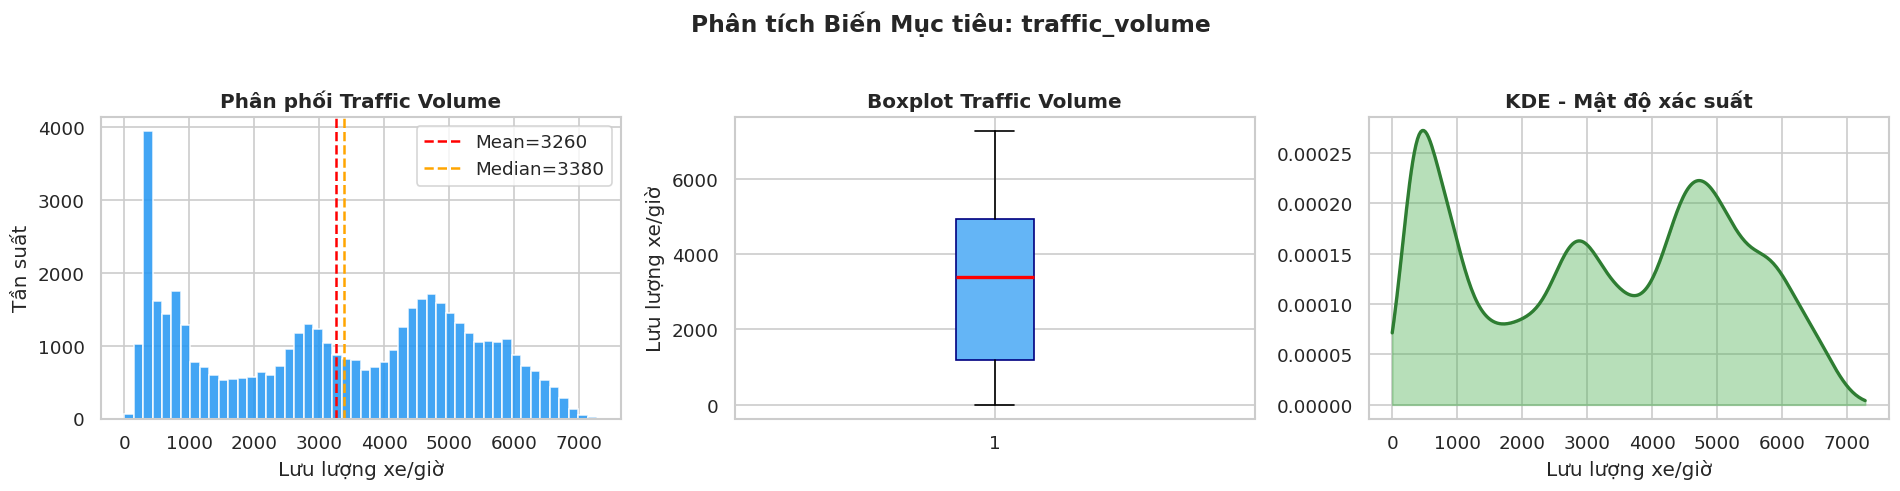

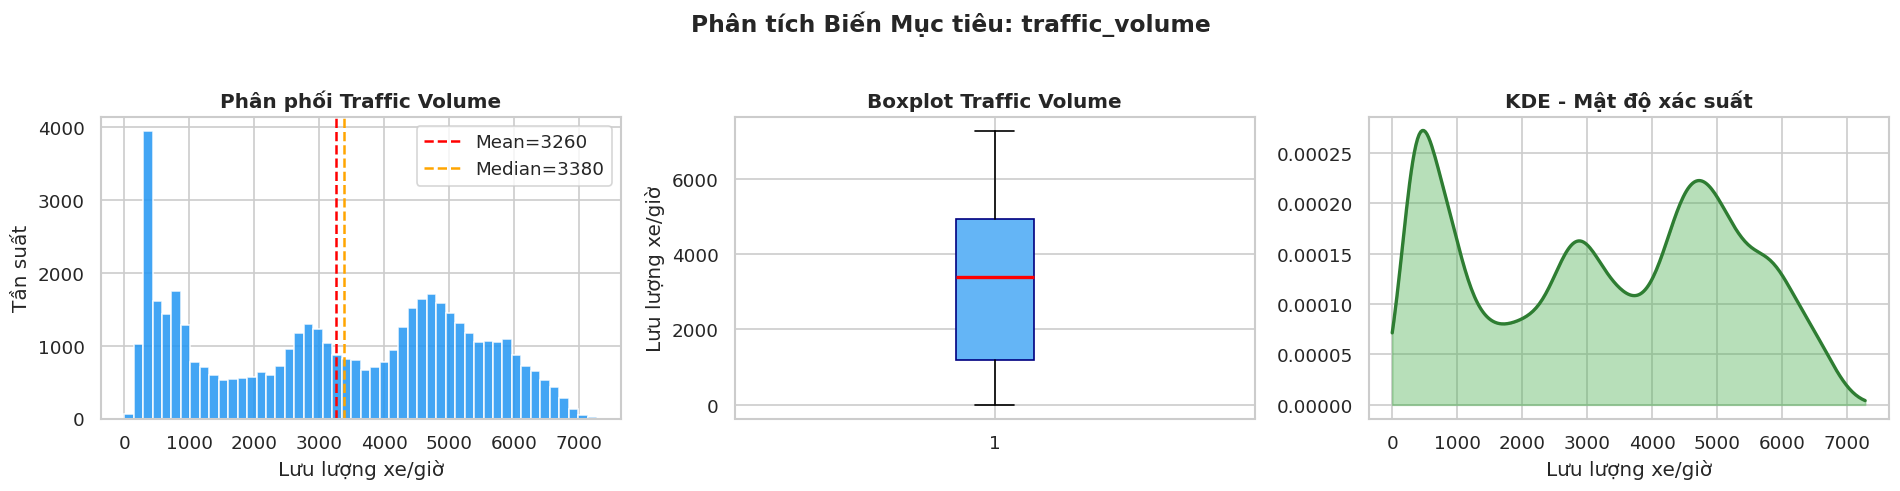

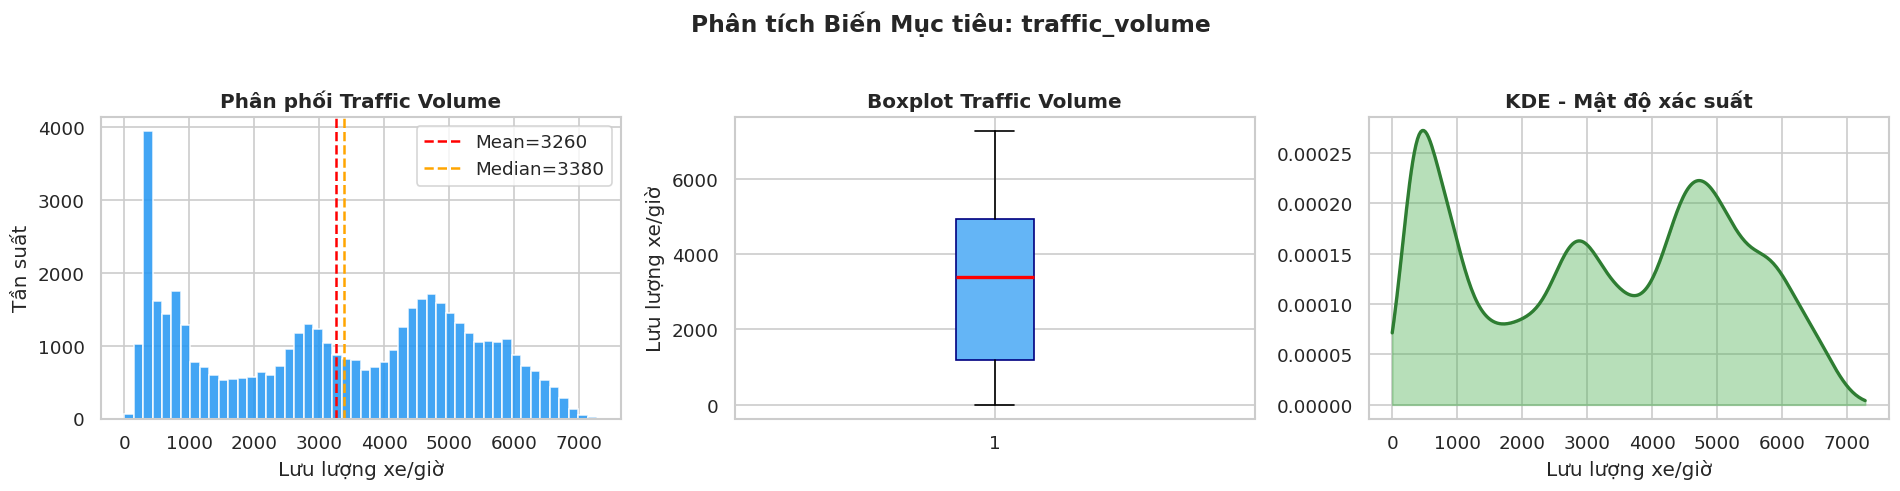


 Thống kê biến mục tiêu:
count    48177.00
mean      3260.02
std       1986.85
min          0.00
25%       1194.00
50%       3380.00
75%       4933.00
max       7280.00
  Skewness: -0.0893
  Kurtosis: -1.3090


In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(df['traffic_volume'], bins=50, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Phân phối Traffic Volume', fontweight='bold')
axes[0].set_xlabel('Lưu lượng xe/giờ')
axes[0].set_ylabel('Tần suất')
axes[0].axvline(df['traffic_volume'].mean(), color='red', linestyle='--', label=f"Mean={df['traffic_volume'].mean():.0f}")
axes[0].axvline(df['traffic_volume'].median(), color='orange', linestyle='--', label=f"Median={df['traffic_volume'].median():.0f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['traffic_volume'], patch_artist=True,
                boxprops=dict(facecolor='#64B5F6', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot Traffic Volume', fontweight='bold')
axes[1].set_ylabel('Lưu lượng xe/giờ')

# KDE
from scipy import stats
kde_x = np.linspace(df['traffic_volume'].min(), df['traffic_volume'].max(), 300)
kde_y = stats.gaussian_kde(df['traffic_volume'])(kde_x)
axes[2].fill_between(kde_x, kde_y, alpha=0.4, color='#4CAF50')
axes[2].plot(kde_x, kde_y, color='#2E7D32', linewidth=2)
axes[2].set_title('KDE - Mật độ xác suất', fontweight='bold')
axes[2].set_xlabel('Lưu lượng xe/giờ')

plt.suptitle('Phân tích Biến Mục tiêu: traffic_volume', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_target_dist.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n Thống kê biến mục tiêu:")
print(df['traffic_volume'].describe().round(2).to_string())
print(f"  Skewness: {df['traffic_volume'].skew():.4f}")
print(f"  Kurtosis: {df['traffic_volume'].kurtosis():.4f}")

## 2.2 Phân tích Biến Số

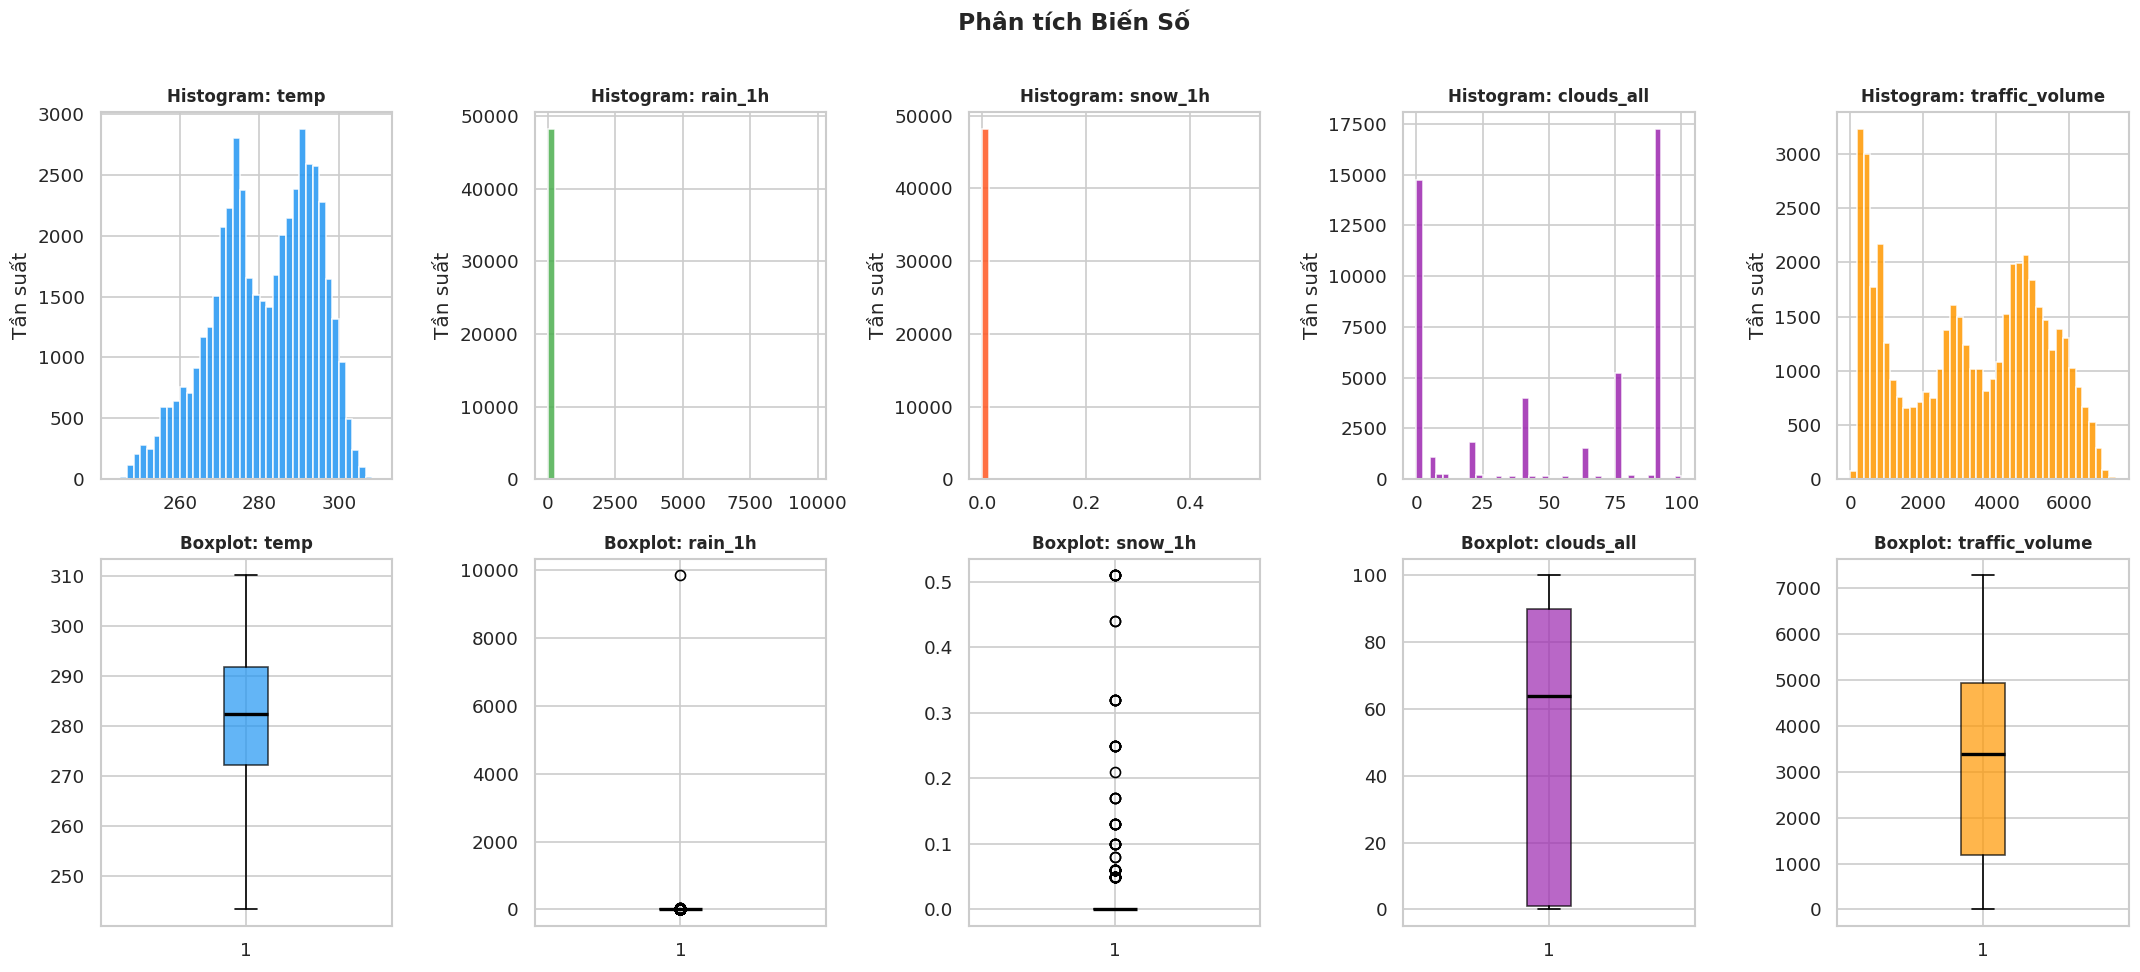

In [58]:
num_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']
fig, axes = plt.subplots(2, len(num_cols), figsize=(18, 8))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=40, color=COLORS[i % len(COLORS)], edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'Histogram: {col}', fontweight='bold', fontsize=10)
    axes[0, i].set_ylabel('Tần suất')

    # Boxplot
    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor=COLORS[i % len(COLORS)], alpha=0.7),
                       medianprops=dict(color='black', linewidth=2))
    axes[1, i].set_title(f'Boxplot: {col}', fontweight='bold', fontsize=10)

plt.suptitle(' Phân tích Biến Số', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_numerical.png', bbox_inches='tight', dpi=150)
plt.show()

## 2.3 Phân tích Biến Thời gian

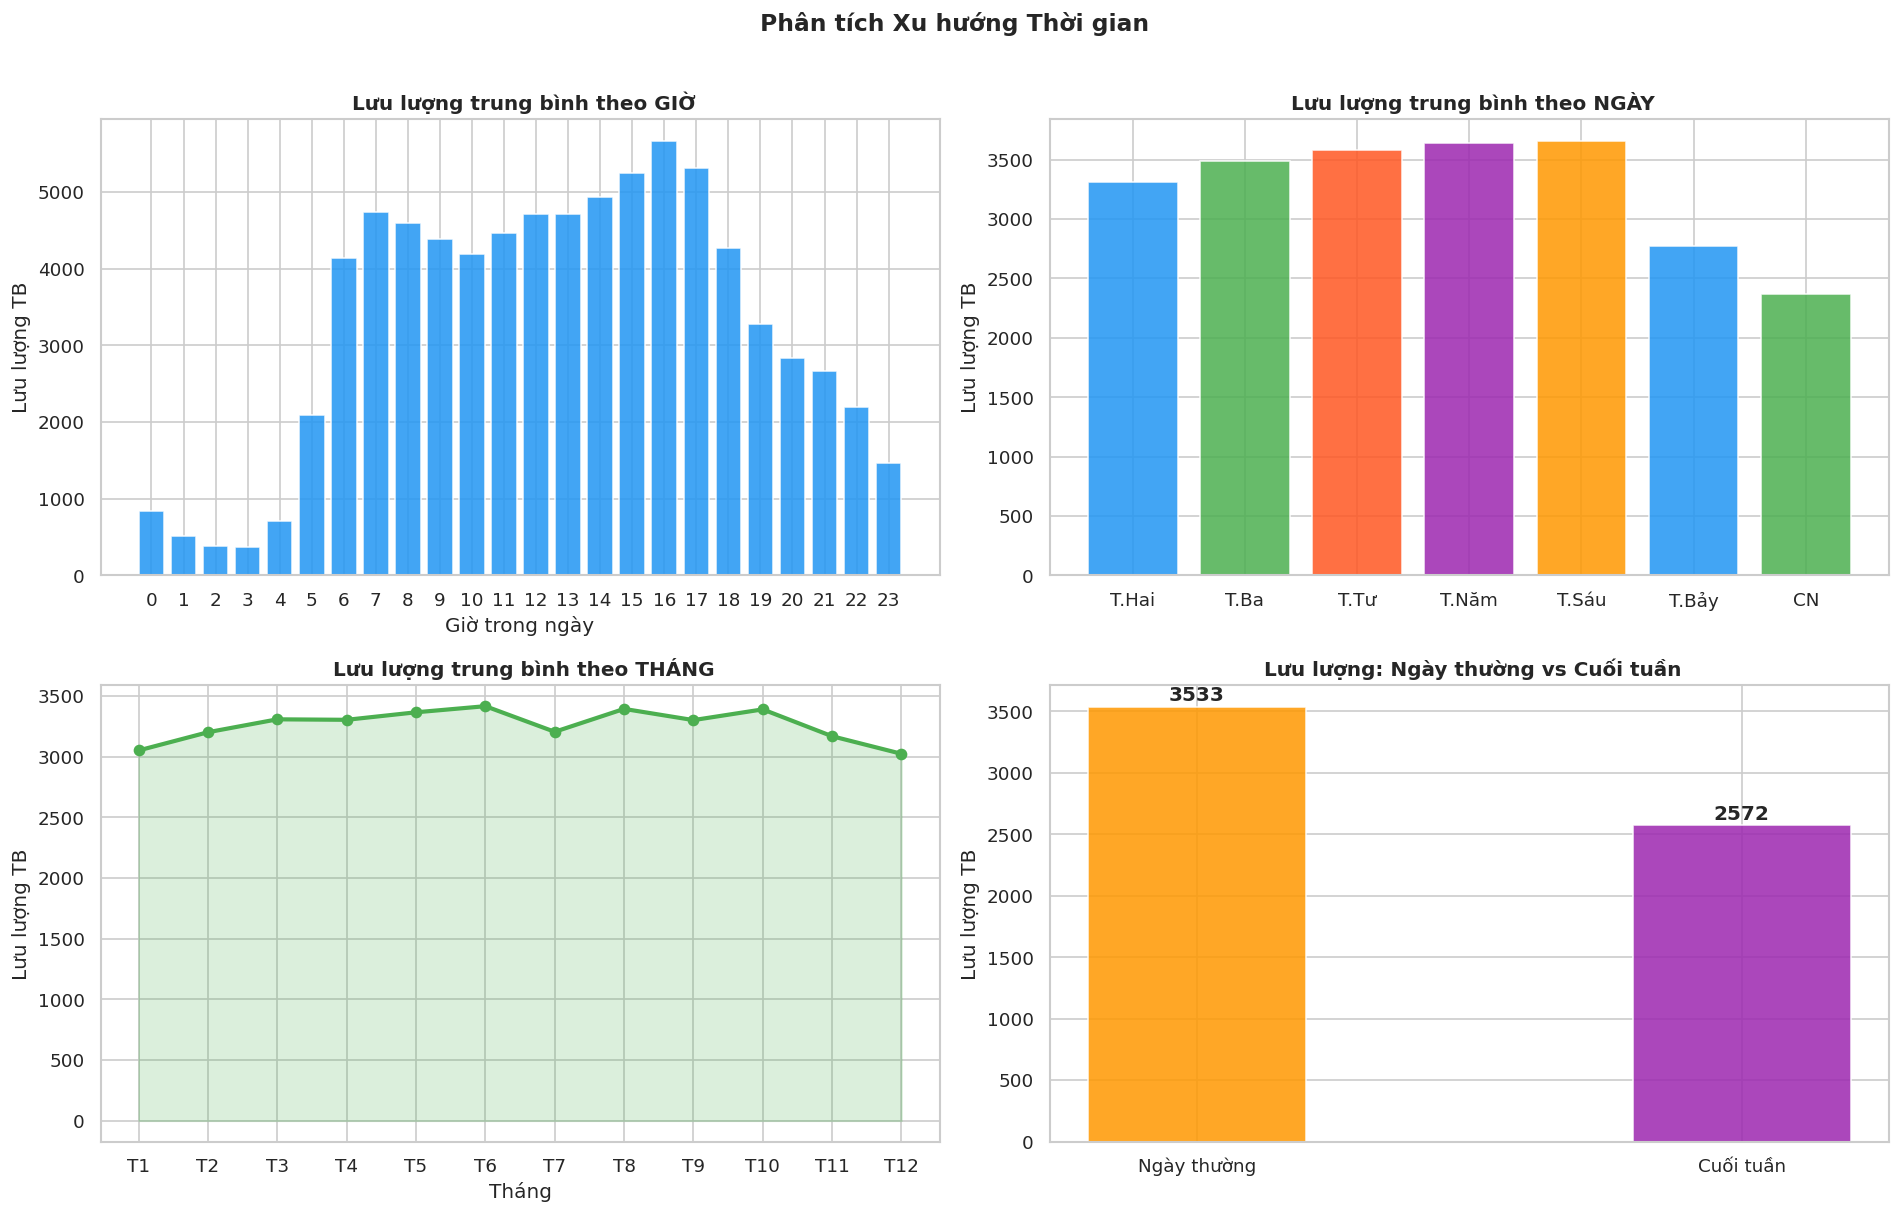

In [59]:
# Trích xuất đặc trưng thời gian trước khi vẽ
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour']    = df['date_time'].dt.hour
df['day']     = df['date_time'].dt.day
df['month']   = df['date_time'].dt.month
df['weekday'] = df['date_time'].dt.weekday   # 0=Thứ 2, 6=Chủ nhật
df['year']    = df['date_time'].dt.year
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Theo giờ
hourly = df.groupby('hour')['traffic_volume'].mean()
axes[0,0].bar(hourly.index, hourly.values, color='#2196F3', alpha=0.85)
axes[0,0].set_title(' Lưu lượng trung bình theo GIỜ', fontweight='bold')
axes[0,0].set_xlabel('Giờ trong ngày'); axes[0,0].set_ylabel('Lưu lượng TB')
axes[0,0].set_xticks(range(24))

# Theo ngày trong tuần
day_names = ['T.Hai','T.Ba','T.Tư','T.Năm','T.Sáu','T.Bảy','CN']
weekly = df.groupby('weekday')['traffic_volume'].mean()
bars = axes[0,1].bar(day_names, weekly.values, color=COLORS, alpha=0.85)
axes[0,1].set_title(' Lưu lượng trung bình theo NGÀY', fontweight='bold')
axes[0,1].set_ylabel('Lưu lượng TB')

# Theo tháng
month_names = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
monthly = df.groupby('month')['traffic_volume'].mean()
axes[1,0].plot(monthly.index, monthly.values, marker='o', color='#4CAF50', linewidth=2.5)
axes[1,0].fill_between(monthly.index, monthly.values, alpha=0.2, color='#4CAF50')
axes[1,0].set_title(' Lưu lượng trung bình theo THÁNG', fontweight='bold')
axes[1,0].set_xlabel('Tháng'); axes[1,0].set_ylabel('Lưu lượng TB')
axes[1,0].set_xticks(range(1, 13)); axes[1,0].set_xticklabels(month_names)

# Ngày thường vs cuối tuần
wknd = df.groupby('is_weekend')['traffic_volume'].mean()
colors_wknd = ['#FF9800', '#9C27B0']
axes[1,1].bar(['Ngày thường', 'Cuối tuần'], wknd.values, color=colors_wknd, alpha=0.85, width=0.4)
axes[1,1].set_title(' Lưu lượng: Ngày thường vs Cuối tuần', fontweight='bold')
axes[1,1].set_ylabel('Lưu lượng TB')
for j, (bar, val) in enumerate(zip(axes[1,1].patches, wknd.values)):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, val + 50, f'{val:.0f}', ha='center', fontweight='bold')

plt.suptitle(' Phân tích Xu hướng Thời gian', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_time_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

## 2.4 Ma trận Tương quan

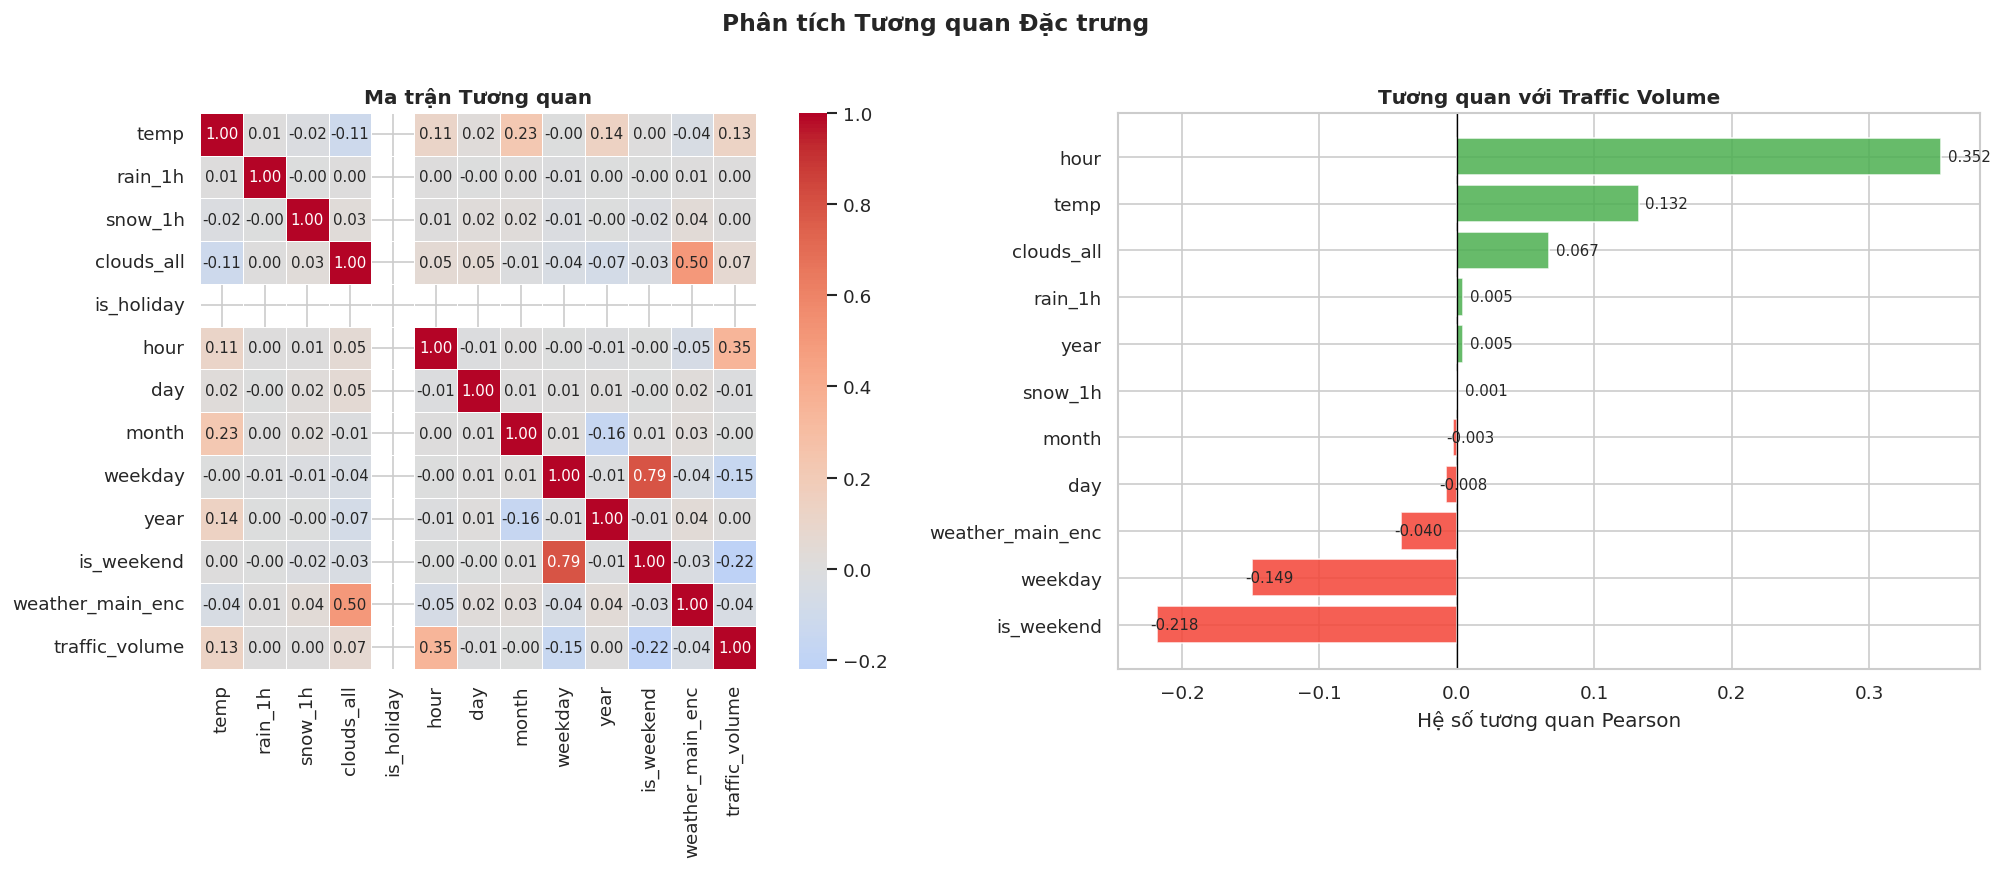

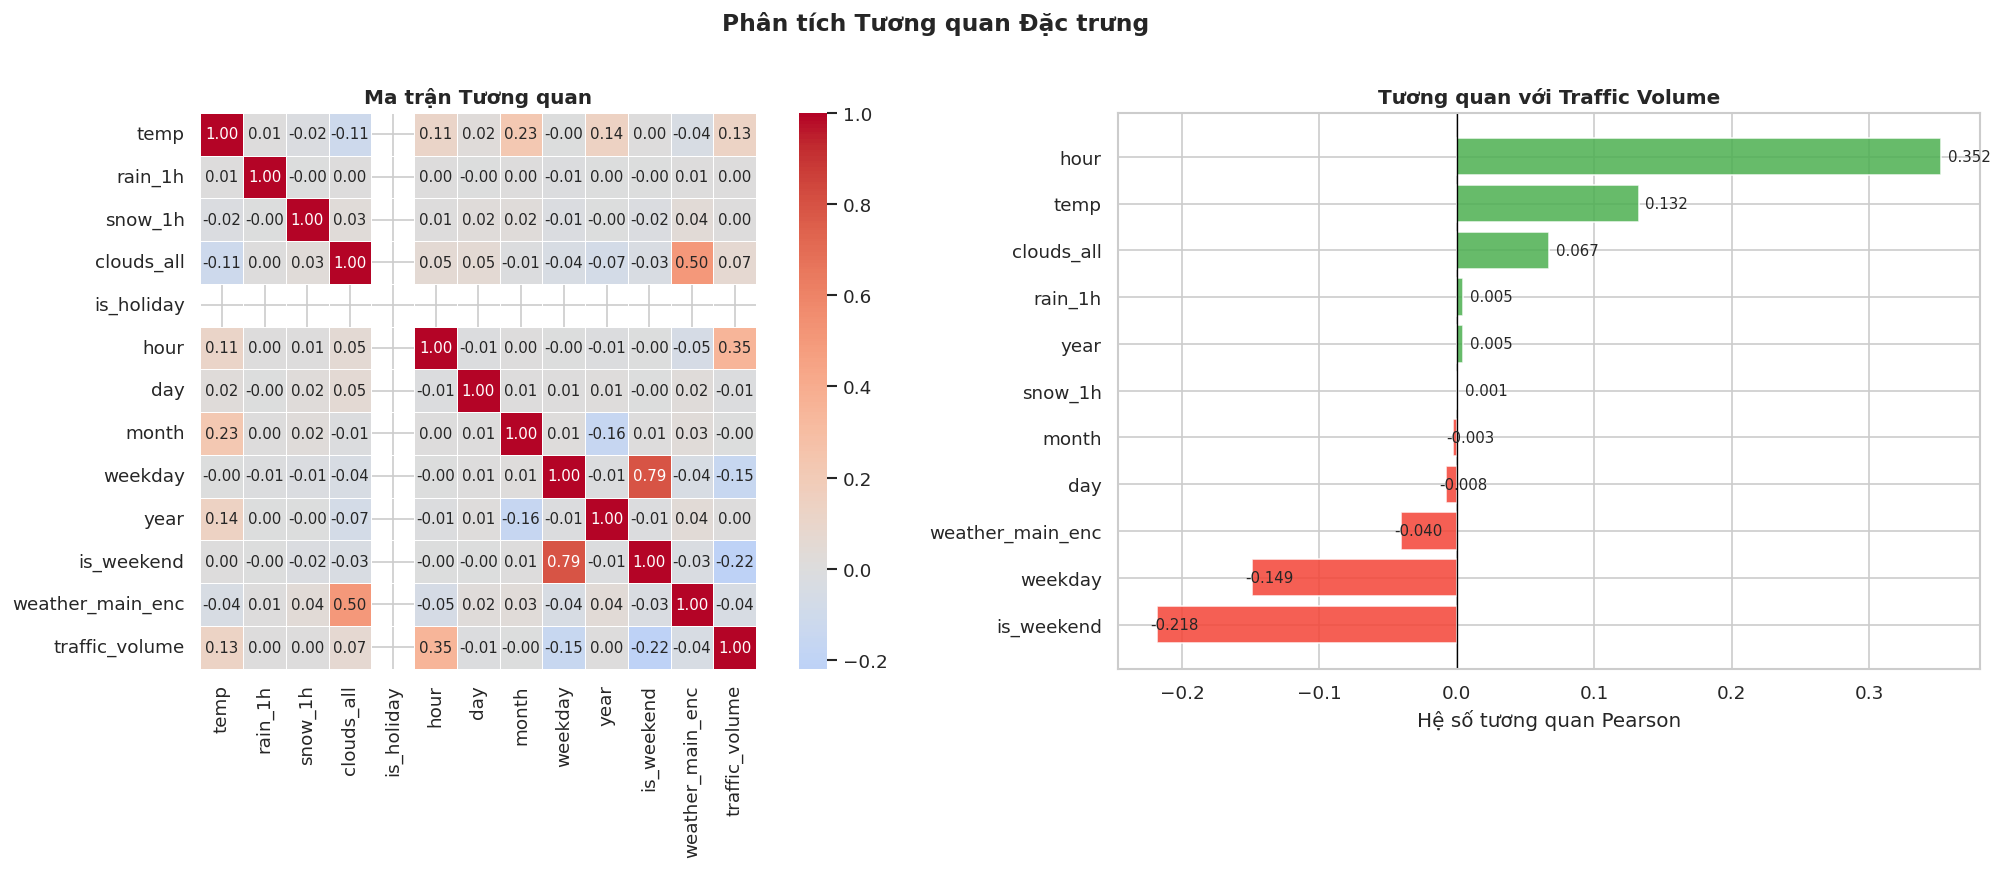


Hệ số tương quan với traffic_volume (sắp xếp theo |r|):
hour                0.3522
is_weekend          0.2184
weekday             0.1493
temp                0.1321
clouds_all          0.0669
weather_main_enc    0.0403
day                 0.0079
rain_1h             0.0047
year                0.0045
month               0.0028
snow_1h             0.0007
is_holiday             NaN


In [61]:
# Mã hóa tạm thời để tính correlation
df_corr = df.copy()
le_tmp = LabelEncoder()
df_corr['weather_main_enc'] = le_tmp.fit_transform(df_corr['weather_main'])
df_corr.drop(columns=['weather_main', 'date_time'], inplace=True)

# ── Sắp xếp lại: traffic_volume xuống cuối cùng ──────────────
cols_ordered = [c for c in df_corr.columns if c != 'traffic_volume'] + ['traffic_volume']
df_corr = df_corr[cols_ordered]

corr_matrix = df_corr.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full correlation heatmap — KHÔNG dùng mask
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0],
            linewidths=0.5, square=True, annot_kws={'size': 9})
axes[0].set_title('Ma trận Tương quan', fontweight='bold')

# Correlation với biến mục tiêu
target_corr = corr_matrix['traffic_volume'].drop('traffic_volume').sort_values(ascending=True)
colors_bar = ['#F44336' if v < 0 else '#4CAF50' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Tương quan với Traffic Volume', fontweight='bold')
axes[1].set_xlabel('Hệ số tương quan Pearson')
for i, (v, name) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(v + 0.005 * np.sign(v), i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Phân tích Tương quan Đặc trưng', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nHệ số tương quan với traffic_volume (sắp xếp theo |r|):")
print(target_corr.abs().sort_values(ascending=False).round(4).to_string())

## 2.5 Xử lý Dữ liệu Thiếu

In [62]:
print(" Kiểm tra missing sau tiền xử lý:")
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0])
if missing_after.sum() == 0:
    print(" Không có giá trị thiếu!")
else:
    # Impute nếu có missing
    for col in df.select_dtypes(include='number').columns:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print(f" Đã xử lý giá trị thiếu (số: median, phân loại: mode)")

 Kiểm tra missing sau tiền xử lý:
Series([], dtype: int64)
 Không có giá trị thiếu!


## 2.6 Mã hóa Biến Phân loại

In [63]:
# ============================================================
# MÃ HÓA BIẾN PHÂN LOẠI
# ============================================================
print(" Mã hóa biến phân loại bằng Label Encoding:")
df_model = df.drop(columns=['date_time'])  # Bỏ cột thời gian gốc

le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"{col}: mã hóa xong ({df_model[col].nunique()} nhãn)")

print(f"\nDữ liệu sẵn sàng cho mô hình: {df_model.shape}")
print(f"Các features: {[c for c in df_model.columns if c != 'traffic_volume']}")
df_model.head(3)

 Mã hóa biến phân loại bằng Label Encoding:
weather_main: mã hóa xong (11 nhãn)

Dữ liệu sẵn sàng cho mô hình: (48177, 13)
Các features: ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'is_holiday', 'hour', 'day', 'month', 'weekday', 'year', 'is_weekend']


,temp,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,is_holiday,hour,day,month,weekday,year,is_weekend
0,288.28,0.0,0.0,40,1,5545,1,9,2,10,1,2012,0
1,289.36,0.0,0.0,75,1,4516,1,10,2,10,1,2012,0
2,289.58,0.0,0.0,90,1,4767,1,11,2,10,1,2012,0


## 2.7 Trích xuất Đặc trưng Thời gian

In [64]:
# Đặc trưng thời gian đã được trích xuất ở mục 2.3
# Thêm cyclical encoding để biểu diễn đặc trưng tuần hoàn
df_model['hour_sin']    = np.sin(2 * np.pi * df_model['hour'] / 24)
df_model['hour_cos']    = np.cos(2 * np.pi * df_model['hour'] / 24)
df_model['month_sin']   = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos']   = np.cos(2 * np.pi * df_model['month'] / 12)
df_model['weekday_sin'] = np.sin(2 * np.pi * df_model['weekday'] / 7)
df_model['weekday_cos'] = np.cos(2 * np.pi * df_model['weekday'] / 7)

print("Đã thêm Cyclical Encoding cho: hour, month, weekday")
print(f"   Tổng số features: {df_model.shape[1] - 1} (không tính target)")
print(f"   Danh sách features: {[c for c in df_model.columns if c != 'traffic_volume']}")

Đã thêm Cyclical Encoding cho: hour, month, weekday
   Tổng số features: 18 (không tính target)
   Danh sách features: ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'is_holiday', 'hour', 'day', 'month', 'weekday', 'year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']


## 2.8 Chuẩn hóa Dữ liệu

In [65]:
# ============================================================
# CHUẨN BỊ X, y VÀ CHIA TẬP DỮ LIỆU
# ============================================================
FEATURE_COLS = [c for c in df_model.columns if c != 'traffic_volume']
TARGET_COL   = 'traffic_volume'

X = df_model[FEATURE_COLS].values
y = df_model[TARGET_COL].values

# Chia Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Chuẩn hóa
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Chuẩn hóa dữ liệu hoàn tất (StandardScaler)")
print(f"   X_train: {X_train_sc.shape} | X_test: {X_test_sc.shape}")
print(f"   y_train: min={y_train.min()}, max={y_train.max()}, mean={y_train.mean():.1f}")
print(f"   y_test : min={y_test.min()}, max={y_test.max()}, mean={y_test.mean():.1f}")

Chuẩn hóa dữ liệu hoàn tất (StandardScaler)
   X_train: (38541, 18) | X_test: (9636, 18)
   y_train: min=0, max=7280, mean=3258.7
   y_test : min=1, max=7260, mean=3265.3


---
# PHẦN 3: XÂY DỰNG MÔ HÌNH BASELINE

## 3.1 Định nghĩa Hàm Đánh giá & Hàm MAPE

In [66]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(model, X_tr, y_tr, X_te, y_te, name='Model'):
    """Đánh giá mô hình với 4 chỉ số"""
    pred_te = model.predict(X_te)
    pred_tr = model.predict(X_tr)
    return {
        'Model' : name,
        'R²_train' : r2_score(y_tr, pred_tr),
        'R²_test'  : r2_score(y_te, pred_te),
        'RMSE_test': np.sqrt(mean_squared_error(y_te, pred_te)),
        'MAE_test' : mean_absolute_error(y_te, pred_te),
        'MAPE_test': mape(y_te, pred_te)
    }

print("Định nghĩa hàm đánh giá mô hình (R², RMSE, MAE, MAPE)")

Định nghĩa hàm đánh giá mô hình (R², RMSE, MAE, MAPE)


## 3.2 Huấn luyện 10 Mô hình Baseline

In [67]:
# ============================================================
# ĐỊNH NGHĨA 10 MÔ HÌNH BASELINE
# ============================================================
baseline_models = {
    '01. Linear Regression'      : LinearRegression(),
    '02. Ridge Regression'       : Ridge(alpha=1.0),
    '03. Lasso Regression'       : Lasso(alpha=1.0),
    '04. Decision Tree'          : DecisionTreeRegressor(max_depth=10, random_state=42),
    '05. Random Forest'          : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    '06. Gradient Boosting'      : GradientBoostingRegressor(n_estimators=100, random_state=42),
    '07. XGBoost'                : xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    '08. LightGBM'               : lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    '09. K-Nearest Neighbors'    : KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
    '10. Extra Trees'            : ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    '11. AdaBoost'               : AdaBoostRegressor(n_estimators=100, random_state=42),
    '12. Bayesian Ridge'         : BayesianRidge(),
}

# ============================================================
# HUẤN LUYỆN & ĐÁNH GIÁ
# ============================================================
import time
results_baseline = []
trained_models   = {}

print(f"{'Mô hình':<30} {'R²_train':>10} {'R²_test':>10} {'RMSE':>10} {'MAE':>10} {'MAPE%':>8} {'Time':>7}")
print("-" * 90)

for name, model in baseline_models.items():
    t0 = time.time()
    # KNN & Linear → dùng dữ liệu đã scale
    use_scaled = name in ['01. Linear Regression', '02. Ridge Regression',
                          '03. Lasso Regression', '09. K-Nearest Neighbors',
                          '12. Bayesian Ridge']
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test

    model.fit(Xtr, y_train)
    trained_models[name] = (model, use_scaled)
    res = evaluate_model(model, Xtr, y_train, Xte, y_test, name)
    res['time'] = time.time() - t0
    results_baseline.append(res)

    print(f"{name:<30} {res['R²_train']:>10.4f} {res['R²_test']:>10.4f} "
          f"{res['RMSE_test']:>10.1f} {res['MAE_test']:>10.1f} "
          f"{res['MAPE_test']:>8.2f} {res['time']:>6.1f}s")

df_results = pd.DataFrame(results_baseline)
df_results.to_csv('/content/drive/MyDrive/MachineLearning/baseline_results.csv', index=False)
print(f"\nKết quả đã lưu vào Drive!")

Mô hình                          R²_train    R²_test       RMSE        MAE    MAPE%    Time
------------------------------------------------------------------------------------------
01. Linear Regression              0.7181     0.7181     1057.2      821.9   183.32    0.1s
02. Ridge Regression               0.7181     0.7181     1057.2      821.9   183.32    0.1s
03. Lasso Regression               0.7180     0.7181     1057.3      822.0   183.28    0.1s
04. Decision Tree                  0.9549     0.9475      456.3      269.0   126.53    0.2s
05. Random Forest                  0.9961     0.9726      329.9      187.0   115.35   24.9s
06. Gradient Boosting              0.9403     0.9436      473.0      305.0   132.88   12.1s
07. XGBoost                        0.9821     0.9751      314.2      197.8   100.44    1.6s
08. LightGBM                       0.9737     0.9710      339.1      214.9    95.11    3.0s
09. K-Nearest Neighbors            0.9180     0.8943      647.4      453.2   143.

## 3.3 Thống kê & So sánh Kết quả Mô hình

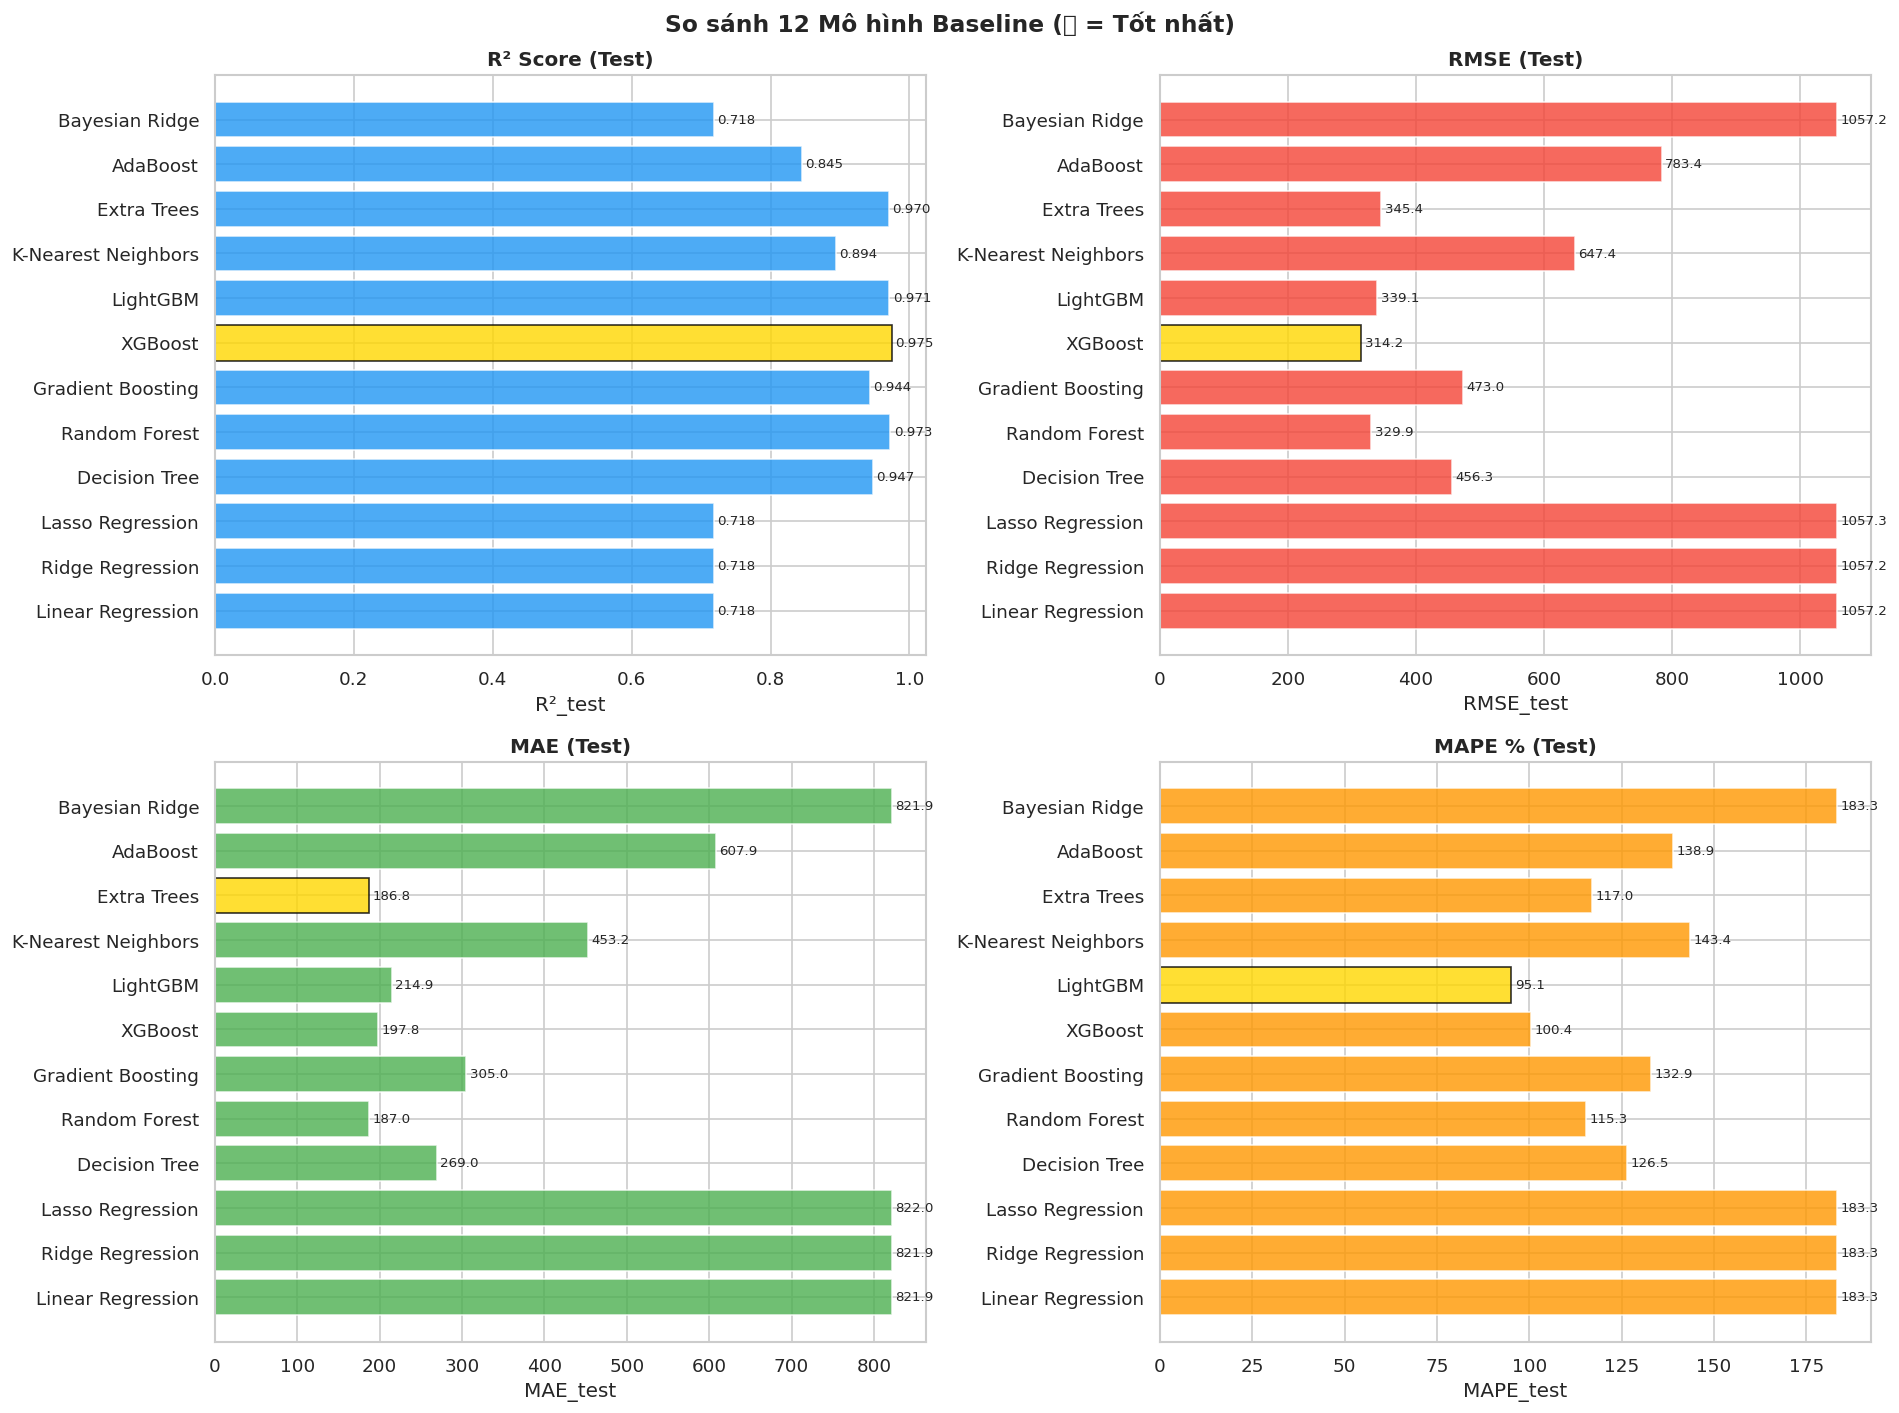


 BẢNG XẾP HẠNG MÔ HÌNH (Theo R² Test):
                  Model  R²_train  R²_test  RMSE_test  MAE_test  MAPE_test
            07. XGBoost    0.9821   0.9751   314.1882  197.8317   100.4421
      05. Random Forest    0.9961   0.9726   329.8942  186.9881   115.3486
           08. LightGBM    0.9737   0.9710   339.1307  214.9271    95.1127
        10. Extra Trees    1.0000   0.9699   345.4485  186.7771   116.9643
      04. Decision Tree    0.9549   0.9475   456.3020  269.0293   126.5327
  06. Gradient Boosting    0.9403   0.9436   473.0088  305.0206   132.8847
09. K-Nearest Neighbors    0.9180   0.8943   647.3907  453.2445   143.4227
           11. AdaBoost    0.8459   0.8452   783.4130  607.8977   138.8560
  01. Linear Regression    0.7181   0.7181  1057.2096  821.9215   183.3172
   02. Ridge Regression    0.7181   0.7181  1057.2100  821.9222   183.3186
     12. Bayesian Ridge    0.7181   0.7181  1057.2125  821.9268   183.3281
   03. Lasso Regression    0.7180   0.7181  1057.2786  822.0

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
model_names_short = [m.split('. ')[1] for m in df_results['Model']]

metrics = [
    ('R²_test',   'R² Score (Test)',   '#2196F3', True),
    ('RMSE_test', 'RMSE (Test)',        '#F44336', False),
    ('MAE_test',  'MAE (Test)',         '#4CAF50', False),
    ('MAPE_test', 'MAPE % (Test)',      '#FF9800', False),
]

for ax, (metric, title, color, higher_better) in zip(axes.flat, metrics):
    vals = df_results[metric].values
    bars = ax.barh(model_names_short, vals, color=color, alpha=0.8)
    best_idx = np.argmax(vals) if higher_better else np.argmin(vals)
    bars[best_idx].set_color('#FFD700')  # Highlight best
    bars[best_idx].set_edgecolor('black')
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(val + max(vals)*0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}' if metric == 'R²_test' else f'{val:.1f}',
                va='center', fontsize=8)

plt.suptitle('So sánh 12 Mô hình Baseline (⭐ = Tốt nhất)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_baseline_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n BẢNG XẾP HẠNG MÔ HÌNH (Theo R² Test):")
print(df_results[['Model','R²_train','R²_test','RMSE_test','MAE_test','MAPE_test']]
      .sort_values('R²_test', ascending=False)
      .to_string(index=False, float_format='{:.4f}'.format))

## 3.4 Lựa chọn Mô hình Tối ưu

In [69]:
# Chọn mô hình tốt nhất theo R² test
best_row = df_results.sort_values('R²_test', ascending=False).iloc[0]
BEST_MODEL_NAME = best_row['Model']
print("=" * 65)
print(f"MÔ HÌNH ĐƯỢC CHỌN: {BEST_MODEL_NAME}")
print("=" * 65)
print(f"  R² (Train) : {best_row['R²_train']:.4f}")
print(f"  R² (Test)  : {best_row['R²_test']:.4f}")
print(f"  RMSE (Test): {best_row['RMSE_test']:.2f}")
print(f"  MAE  (Test): {best_row['MAE_test']:.2f}")
print(f"  MAPE (Test): {best_row['MAPE_test']:.2f}%")

# Lấy mô hình và dữ liệu tương ứng
best_model_obj, best_use_scaled = trained_models[BEST_MODEL_NAME]
X_tr_best = X_train_sc if best_use_scaled else X_train
X_te_best = X_test_sc  if best_use_scaled else X_test

MÔ HÌNH ĐƯỢC CHỌN: 07. XGBoost
  R² (Train) : 0.9821
  R² (Test)  : 0.9751
  RMSE (Test): 314.19
  MAE  (Test): 197.83
  MAPE (Test): 100.44%


---
# PHẦN 4: TINH CHỈNH MÔ HÌNH

## 4.1 GridSearchCV — Tìm Siêu tham số Tốt nhất

In [70]:
from sklearn.metrics import make_scorer

# Dùng XGBoost làm mô hình tinh chỉnh (thường top 1-2)
best_estimator_base = xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
X_tune = X_train  # XGBoost không cần scale
X_tune_test = X_test

# Grid Search
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
}

print(" Đang chạy GridSearchCV (có thể mất vài phút)...")
t0 = time.time()
grid_search = GridSearchCV(
    best_estimator_base, param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0,
    return_train_score=True
)
grid_search.fit(X_tune, y_train)
t_grid = time.time() - t0

print(f" GridSearchCV hoàn tất trong {t_grid:.1f}s")
print(f"   Best R² (CV): {grid_search.best_score_:.4f}")
print(f"   Best params : {grid_search.best_params_}")

# Lấy top 5 bộ siêu tham số
cv_results_grid = pd.DataFrame(grid_search.cv_results_)
top5_grid = cv_results_grid.nlargest(5, 'mean_test_score')[[
    'params', 'mean_test_score', 'std_test_score', 'mean_train_score'
]].reset_index(drop=True)
top5_grid.index = [f'Top {i+1}' for i in range(len(top5_grid))]
print("\nTop 5 bộ siêu tham số (GridSearchCV):")
print(top5_grid.round(4).to_string())

# Đánh giá mô hình best từ Grid
best_grid_model = grid_search.best_estimator_
res_grid = evaluate_model(best_grid_model, X_tune, y_train, X_tune_test, y_test, 'XGB + GridSearch')
print(f"\n  Test R²={res_grid['R²_test']:.4f} | RMSE={res_grid['RMSE_test']:.1f} | MAE={res_grid['MAE_test']:.1f}")

⏳ Đang chạy GridSearchCV (có thể mất vài phút)...
 GridSearchCV hoàn tất trong 138.4s
   Best R² (CV): 0.9806
   Best params : {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300}

Top 5 bộ siêu tham số (GridSearchCV):
                                                            params  mean_test_score  std_test_score  mean_train_score
Top 1  {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300}           0.9806          0.0010            0.9944
Top 2  {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}           0.9794          0.0011            0.9918
Top 3  {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}           0.9784          0.0010            0.9894
Top 4  {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}           0.9766          0.0010            0.9860
Top 5  {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100}           0.9763          0.0014            0.9860

  Test R²=0.9815 | RMSE=270.8 | MAE=167.4


## 4.2 RandomizedSearchCV — Tìm Siêu tham số Tốt nhất

In [71]:
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators'       : randint(100, 500),
    'max_depth'          : randint(3, 10),
    'learning_rate'      : uniform(0.01, 0.3),
    'subsample'          : uniform(0.6, 0.4),
    'colsample_bytree'   : uniform(0.6, 0.4),
    'min_child_weight'   : randint(1, 10),
}

print("Đang chạy RandomizedSearchCV (n_iter=50)...")
t0 = time.time()
random_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    param_dist, n_iter=50, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0,
    return_train_score=True
)
random_search.fit(X_tune, y_train)
t_rand = time.time() - t0

print(f"RandomizedSearchCV hoàn tất trong {t_rand:.1f}s")
print(f"   Best R² (CV): {random_search.best_score_:.4f}")
print(f"   Best params : {random_search.best_params_}")

cv_results_rand = pd.DataFrame(random_search.cv_results_)
top5_rand = cv_results_rand.nlargest(5, 'mean_test_score')[[
    'params', 'mean_test_score', 'std_test_score'
]].reset_index(drop=True)
top5_rand.index = [f'Top {i+1}' for i in range(len(top5_rand))]
print("\nTop 5 bộ siêu tham số (RandomizedSearch):")
print(top5_rand.round(4).to_string())

best_rand_model = random_search.best_estimator_
res_rand = evaluate_model(best_rand_model, X_tune, y_train, X_tune_test, y_test, 'XGB + RandomSearch')
print(f"\n  Test R²={res_rand['R²_test']:.4f} | RMSE={res_rand['RMSE_test']:.1f} | MAE={res_rand['MAE_test']:.1f}")

Đang chạy RandomizedSearchCV (n_iter=50)...
RandomizedSearchCV hoàn tất trong 365.3s
   Best R² (CV): 0.9827
   Best params : {'colsample_bytree': np.float64(0.9906459823330611), 'learning_rate': np.float64(0.1333111039954694), 'max_depth': 9, 'min_child_weight': 5, 'n_estimators': 323, 'subsample': np.float64(0.9633063543866615)}

Top 5 bộ siêu tham số (RandomizedSearch):
                                                                                                                                                                            params  mean_test_score  std_test_score
Top 1   {'colsample_bytree': 0.9906459823330611, 'learning_rate': 0.1333111039954694, 'max_depth': 9, 'min_child_weight': 5, 'n_estimators': 323, 'subsample': 0.9633063543866615}           0.9827          0.0007
Top 2  {'colsample_bytree': 0.9933692563579372, 'learning_rate': 0.12964733273336593, 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.7283120259886944}           0.9826     

## 4.3 Bayesian Optimization — Tìm Siêu tham số Tốt nhất

In [72]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

bayes_space = {
    'n_estimators'    : Integer(100, 500),
    'max_depth'       : Integer(3, 10),
    'learning_rate'   : Real(0.01, 0.3, prior='log-uniform'),
    'subsample'       : Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'min_child_weight': Integer(1, 10),
    'reg_alpha'       : Real(1e-5, 10, prior='log-uniform'),
    'reg_lambda'      : Real(1e-5, 10, prior='log-uniform'),
}

print("Đang chạy Bayesian Optimization (n_iter=40)...")
t0 = time.time()
bayes_search = BayesSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    bayes_space, n_iter=40, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0,
    return_train_score=True
)
bayes_search.fit(X_tune, y_train)
t_bayes = time.time() - t0

print(f"Bayesian Optimization hoàn tất trong {t_bayes:.1f}s")
print(f"   Best R² (CV): {bayes_search.best_score_:.4f}")
print(f"   Best params : {dict(bayes_search.best_params_)}")

cv_results_bayes = pd.DataFrame(bayes_search.cv_results_)
top5_bayes = cv_results_bayes.nlargest(5, 'mean_test_score')[[
    'params', 'mean_test_score', 'std_test_score'
]].reset_index(drop=True)
top5_bayes.index = [f'Top {i+1}' for i in range(len(top5_bayes))]
print("\nTop 5 bộ siêu tham số (Bayesian Optimization):")
print(top5_bayes.round(4).to_string())

best_bayes_model = bayes_search.best_estimator_
res_bayes = evaluate_model(best_bayes_model, X_tune, y_train, X_tune_test, y_test, 'XGB + Bayesian')
print(f"\n  Test R²={res_bayes['R²_test']:.4f} | RMSE={res_bayes['RMSE_test']:.1f} | MAE={res_bayes['MAE_test']:.1f}")

Đang chạy Bayesian Optimization (n_iter=40)...
Bayesian Optimization hoàn tất trong 680.7s
   Best R² (CV): 0.9838
   Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.19704041544027157, 'max_depth': 10, 'min_child_weight': 10, 'n_estimators': 500, 'reg_alpha': 1e-05, 'reg_lambda': 10.0, 'subsample': 0.9088699630138013}

Top 5 bộ siêu tham số (Bayesian Optimization):
                                                                                                                                                                                                                                                params  mean_test_score  std_test_score
Top 1                                           {'colsample_bytree': 1.0, 'learning_rate': 0.19704041544027157, 'max_depth': 10, 'min_child_weight': 10, 'n_estimators': 500, 'reg_alpha': 1e-05, 'reg_lambda': 10.0, 'subsample': 0.9088699630138013}           0.9838          0.0008
Top 2                                                        

## 4.4 So sánh 5 Bộ Siêu tham số Tốt nhất — 3 Phương pháp

In [73]:
print("=" * 70)
print("SO SÁNH KẾT QUẢ 3 PHƯƠNG PHÁP TÌM SIÊU THAM SỐ")
print("=" * 70)

comparison = pd.DataFrame([
    {'Phương pháp': 'GridSearchCV',        'Best CV R²': grid_search.best_score_,
     'Test R²': res_grid['R²_test'],  'Test RMSE': res_grid['RMSE_test'],
     'Test MAE': res_grid['MAE_test'], 'Test MAPE%': res_grid['MAPE_test'],
     'Thời gian (s)': t_grid},
    {'Phương pháp': 'RandomizedSearchCV',  'Best CV R²': random_search.best_score_,
     'Test R²': res_rand['R²_test'],  'Test RMSE': res_rand['RMSE_test'],
     'Test MAE': res_rand['MAE_test'], 'Test MAPE%': res_rand['MAPE_test'],
     'Thời gian (s)': t_rand},
    {'Phương pháp': 'Bayesian Optimization','Best CV R²': bayes_search.best_score_,
     'Test R²': res_bayes['R²_test'], 'Test RMSE': res_bayes['RMSE_test'],
     'Test MAE': res_bayes['MAE_test'],'Test MAPE%': res_bayes['MAPE_test'],
     'Thời gian (s)': t_bayes},
])
print(comparison.round(4).to_string(index=False))



# Chọn mô hình cuối cùng: best từ 3 phương pháp
best_final = comparison.loc[comparison['Test R²'].idxmax(), 'Phương pháp']
print(f" Mô hình tốt nhất được chọn từ: {best_final}")

if best_final == 'GridSearchCV':
    final_model = best_grid_model
elif best_final == 'RandomizedSearchCV':
    final_model = best_rand_model
else:
    final_model = best_bayes_model

SO SÁNH KẾT QUẢ 3 PHƯƠNG PHÁP TÌM SIÊU THAM SỐ
          Phương pháp  Best CV R²  Test R²  Test RMSE  Test MAE  Test MAPE%  Thời gian (s)
         GridSearchCV      0.9806   0.9815   270.7590  167.4078     80.5957       138.4485
   RandomizedSearchCV      0.9827   0.9844   248.7577  149.7900     79.3984       365.2796
Bayesian Optimization      0.9838   0.9852   242.2676  144.5938     75.5836       680.7054
 Mô hình tốt nhất được chọn từ: Bayesian Optimization


## 4.5 Cross-Validation K-Fold (k=5)

In [74]:
# ============================================================
# K-FOLD CROSS VALIDATION (k=5)
# ============================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_metrics = {'R2': [], 'RMSE': [], 'MAE': [], 'MAPE': []}

print(" Chạy 5-Fold Cross Validation...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_tune), 1):
    Xf_tr, Xf_val = X_tune[train_idx], X_tune[val_idx]
    yf_tr, yf_val = y_train[train_idx], y_train[val_idx]

    # Clone và fit
    from sklearn.base import clone
    fold_model = clone(final_model)
    fold_model.fit(Xf_tr, yf_tr)
    yf_pred = fold_model.predict(Xf_val)

    r2   = r2_score(yf_val, yf_pred)
    rmse = np.sqrt(mean_squared_error(yf_val, yf_pred))
    mae  = mean_absolute_error(yf_val, yf_pred)
    mp   = mape(yf_val, yf_pred)

    cv_metrics['R2'].append(r2)
    cv_metrics['RMSE'].append(rmse)
    cv_metrics['MAE'].append(mae)
    cv_metrics['MAPE'].append(mp)
    print(f"  Fold {fold}: R²={r2:.4f} | RMSE={rmse:.1f} | MAE={mae:.1f} | MAPE={mp:.2f}%")

print("\n KẾT QUẢ TRUNG BÌNH 5-FOLD:")
for k, v in cv_metrics.items():
    print(f"  {k}: {np.mean(v):.4f} ± {np.std(v):.4f}")

# Test set
y_pred_test  = final_model.predict(X_tune_test)
y_pred_train = final_model.predict(X_tune)
test_r2   = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae  = mean_absolute_error(y_test, y_pred_test)
test_mape = mape(y_test, y_pred_test)
train_r2   = r2_score(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae  = mean_absolute_error(y_train, y_pred_train)
train_mape = mape(y_train, y_pred_train)

print(f"\n  Test Set: R²={test_r2:.4f} | RMSE={test_rmse:.1f} | MAE={test_mae:.1f} | MAPE={test_mape:.2f}%")
print(f"  Train Set: R²={train_r2:.4f} | RMSE={train_rmse:.1f} | MAE={train_mae:.1f} | MAPE={train_mape:.2f}%")

 Chạy 5-Fold Cross Validation...
  Fold 1: R²=0.9831 | RMSE=256.4 | MAE=155.0 | MAPE=19.26%
  Fold 2: R²=0.9834 | RMSE=255.2 | MAE=156.0 | MAPE=29.46%
  Fold 3: R²=0.9846 | RMSE=248.5 | MAE=152.5 | MAPE=51.35%
  Fold 4: R²=0.9828 | RMSE=261.3 | MAE=155.8 | MAPE=22.39%
  Fold 5: R²=0.9835 | RMSE=254.1 | MAE=154.4 | MAPE=31.42%

 KẾT QUẢ TRUNG BÌNH 5-FOLD:
  R2: 0.9835 ± 0.0006
  RMSE: 255.0790 ± 4.1207
  MAE: 154.7419 ± 1.2656
  MAPE: 30.7760 ± 11.2123

  Test Set: R²=0.9852 | RMSE=242.3 | MAE=144.6 | MAPE=75.58%
  Train Set: R²=0.9993 | RMSE=53.0 | MAE=36.1 | MAPE=5.60%


## 4.6 Chống Overfitting — L1 (Lasso) & L2 (Ridge)

In [75]:
# ============================================================
# CHỐNG OVERFITTING BẰNG L1, L2, ELASTIC NET
# ============================================================
print(" So sánh XGBoost với các mức Regularization L1 (alpha) & L2 (lambda):")
print("-" * 70)

reg_configs = [
    ('Baseline (no reg)',  {'reg_alpha': 0,   'reg_lambda': 1}),
    ('L2 nhẹ (λ=1)',      {'reg_alpha': 0,   'reg_lambda': 1}),
    ('L2 vừa (λ=5)',      {'reg_alpha': 0,   'reg_lambda': 5}),
    ('L2 mạnh (λ=10)',    {'reg_alpha': 0,   'reg_lambda': 10}),
    ('L1 nhẹ (α=0.1)',    {'reg_alpha': 0.1, 'reg_lambda': 0}),
    ('L1 vừa (α=1)',      {'reg_alpha': 1,   'reg_lambda': 0}),
    ('ElasticNet (α=1,λ=1)', {'reg_alpha': 1, 'reg_lambda': 1}),
]

# Bỏ key syntax error – fix:
reg_configs = [
    ('Baseline (no reg)',     {'reg_alpha': 0,   'reg_lambda': 1}),
    ('L2 vừa (λ=5)',         {'reg_alpha': 0,   'reg_lambda': 5}),
    ('L2 mạnh (λ=10)',       {'reg_alpha': 0,   'reg_lambda': 10}),
    ('L1 nhẹ (α=0.1)',       {'reg_alpha': 0.1, 'reg_lambda': 0}),
    ('L1 vừa (α=1)',         {'reg_alpha': 1,   'reg_lambda': 0}),
    ('L1 mạnh (α=5)',        {'reg_alpha': 5,   'reg_lambda': 0}),
    ('ElasticNet (α=1,λ=1)', {'reg_alpha': 1,   'reg_lambda': 1}),
]

best_params_final = final_model.get_params()
reg_results = []
print(f"{'Config':<28} {'R²_train':>10} {'R²_test':>10} {'RMSE_test':>10} {'Gap':>8}")
print("-" * 70)
for label, reg_p in reg_configs:
    params = {**best_params_final, **reg_p}
    m = xgb.XGBRegressor(**{k: v for k, v in params.items() if k != 'verbosity'},
                          verbosity=0)
    m.fit(X_tune, y_train)
    r2_tr = r2_score(y_train, m.predict(X_tune))
    r2_te = r2_score(y_test,  m.predict(X_tune_test))
    rmse  = np.sqrt(mean_squared_error(y_test, m.predict(X_tune_test)))
    gap   = r2_tr - r2_te
    reg_results.append({'Config': label, 'R²_train': r2_tr, 'R²_test': r2_te, 'RMSE': rmse, 'Gap': gap})
    print(f"  {label:<26} {r2_tr:>10.4f} {r2_te:>10.4f} {rmse:>10.1f} {gap:>8.4f}")

print("\n Gap = R²_train - R²_test: Nhỏ → ít overfit, Lớn → đang overfit")

 So sánh XGBoost với các mức Regularization L1 (alpha) & L2 (lambda):
----------------------------------------------------------------------
Config                         R²_train    R²_test  RMSE_test      Gap
----------------------------------------------------------------------
  Baseline (no reg)              0.9996     0.9845      247.8   0.0151
  L2 vừa (λ=5)                   0.9994     0.9850      244.3   0.0145
  L2 mạnh (λ=10)                 0.9993     0.9853      241.3   0.0140
  L1 nhẹ (α=0.1)                 0.9996     0.9843      249.4   0.0153
  L1 vừa (α=1)                   0.9996     0.9843      249.6   0.0153
  L1 mạnh (α=5)                  0.9996     0.9842      250.0   0.0154
  ElasticNet (α=1,λ=1)           0.9996     0.9846      246.8   0.0149

 Gap = R²_train - R²_test: Nhỏ → ít overfit, Lớn → đang overfit


## 4.7 Biểu đồ R², RMSE, MAE, MAPE — 5-fold & Test

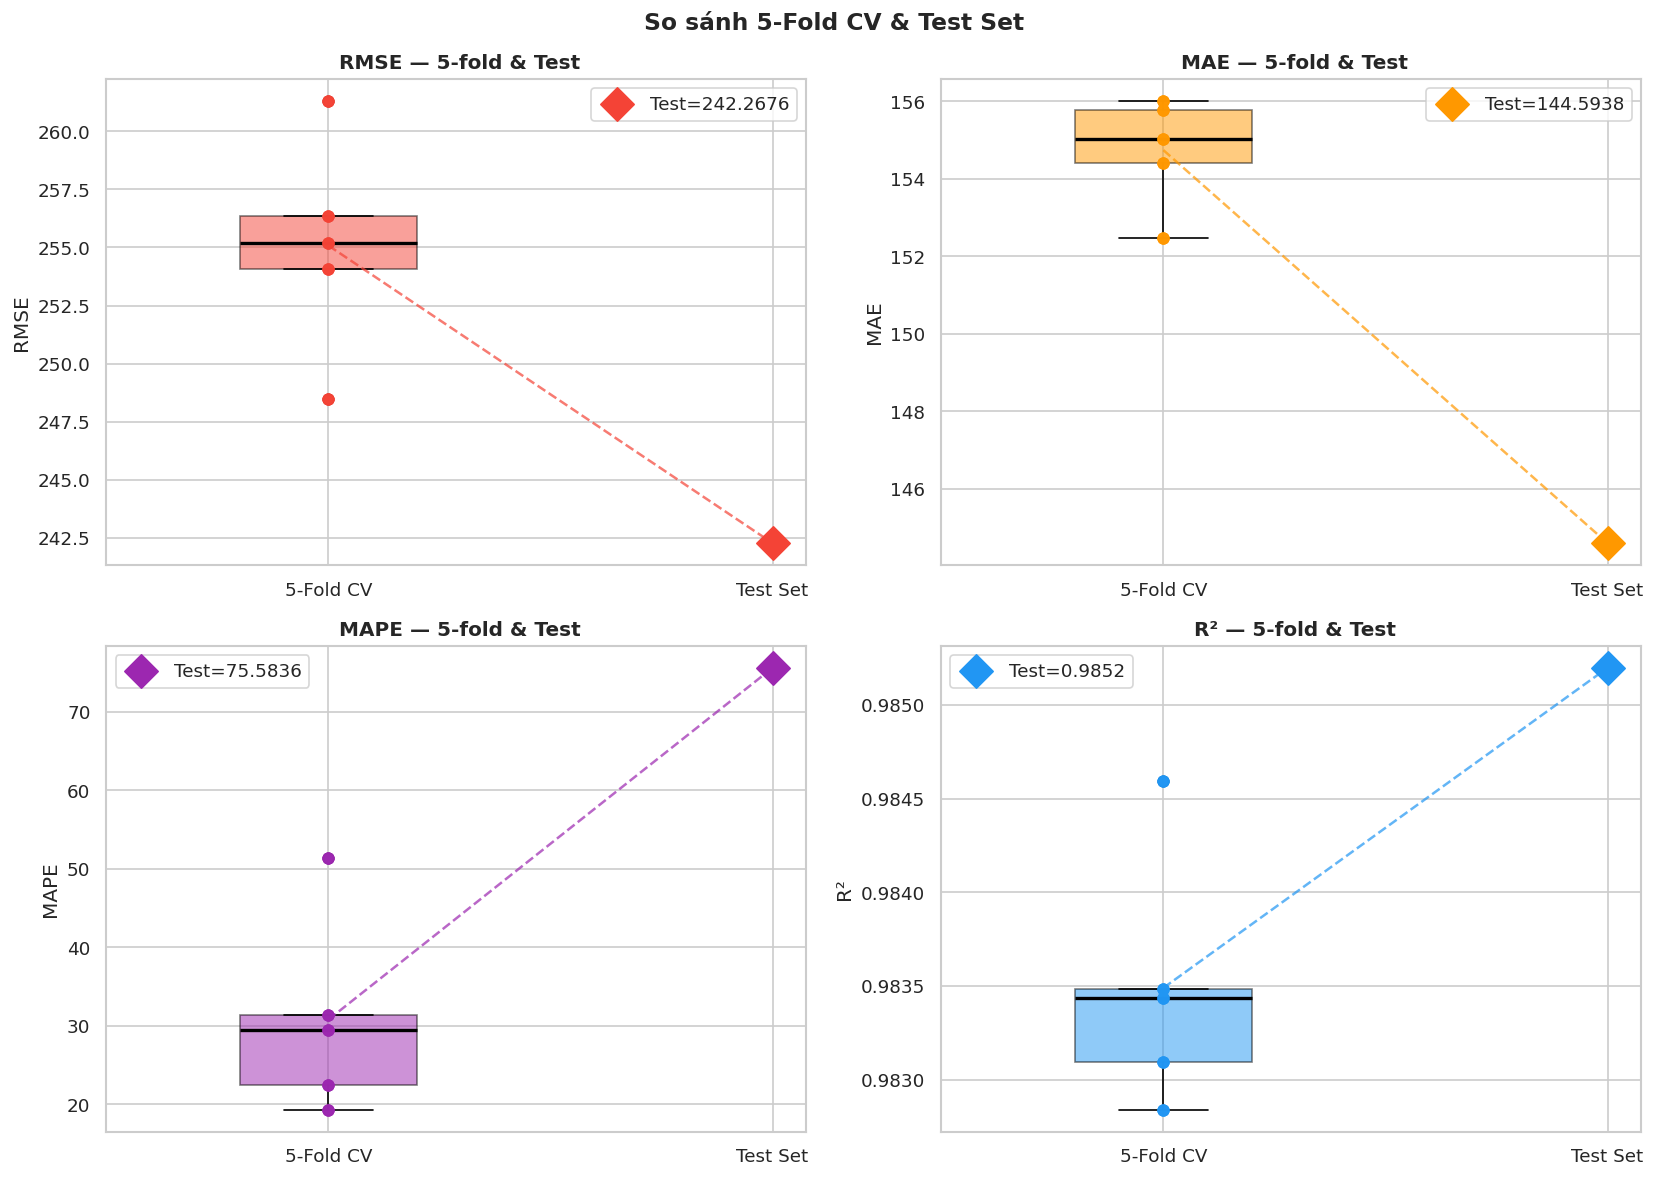

In [76]:
# ============================================================
# BIỂU ĐỒ CẶP: 5-fold vs Test
# ============================================================
metric_pairs = [
    ('RMSE', np.mean(cv_metrics['RMSE']), test_rmse),
    ('MAE',  np.mean(cv_metrics['MAE']),  test_mae),
    ('MAPE', np.mean(cv_metrics['MAPE']), test_mape),
    ('R²',   np.mean(cv_metrics['R2']),   test_r2),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pair_colors = ['#F44336', '#FF9800', '#9C27B0', '#2196F3']

for ax, (metric, cv_val, test_val), color in zip(axes.flat, metric_pairs, pair_colors):
    # Boxplot 5-fold + test point
    cv_data = cv_metrics[metric] if metric != 'R²' else cv_metrics['R2']
    ax.boxplot(cv_data, positions=[1], widths=0.4, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color='black', linewidth=2))
    ax.scatter([2], [test_val], color=color, s=200, zorder=5, marker='D', label=f'Test={test_val:.4f}')
    ax.plot([1, 2], [cv_val, test_val], '--', color=color, alpha=0.7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['5-Fold CV', 'Test Set'])
    ax.set_title(f' {metric} — 5-fold & Test', fontweight='bold')
    ax.set_ylabel(metric)
    ax.legend()
    for i, v in enumerate(cv_data):
        ax.scatter([1]*5, cv_data, color=color, alpha=0.6, s=40, zorder=4)

plt.suptitle(' So sánh 5-Fold CV & Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_cv_test.png', bbox_inches='tight', dpi=150)
plt.show()

## 4.8 Biểu đồ R², RMSE, MAE, MAPE — 5-fold & Test & Train

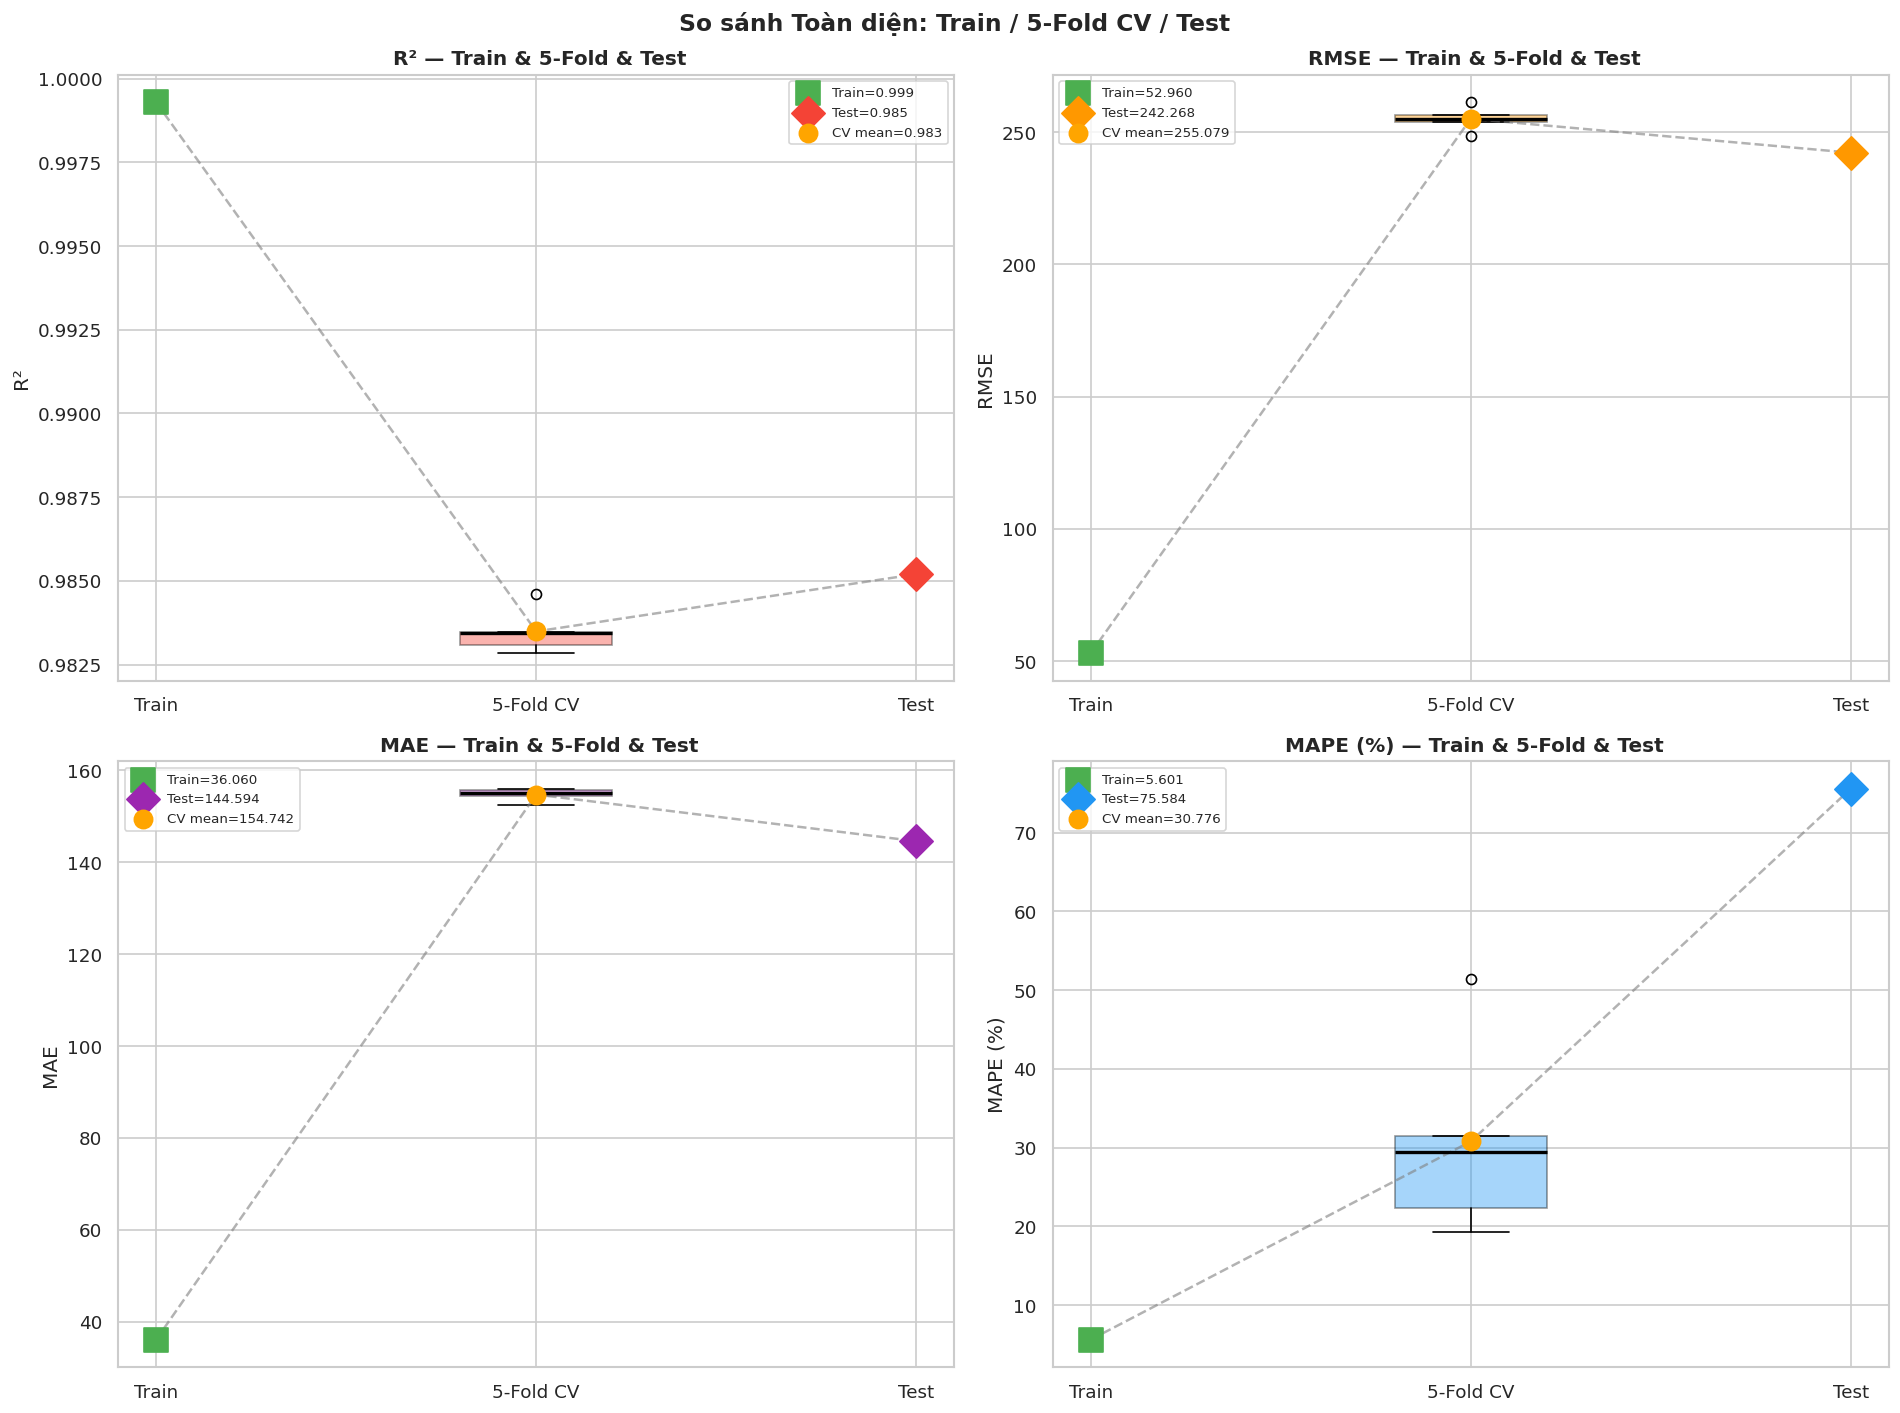

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metric_names = ['R2', 'RMSE', 'MAE', 'MAPE']
metric_labels = ['R²', 'RMSE', 'MAE', 'MAPE (%)']
train_vals_all = [train_r2, train_rmse, train_mae, train_mape]
test_vals_all  = [test_r2,  test_rmse,  test_mae,  test_mape]

for ax, metric, label, tr_val, te_val, color in zip(
    axes.flat, metric_names, metric_labels,
    train_vals_all, test_vals_all, pair_colors
):
    cv_data = cv_metrics[metric]
    x = [1, 2, 3]
    labels_x = ['Train', '5-Fold CV', 'Test']

    # Vẽ boxplot cho CV
    ax.boxplot(cv_data, positions=[2], widths=0.4, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.4),
               medianprops=dict(color='black', linewidth=2))

    # Scatter train & test
    ax.scatter([1], [tr_val], color='#4CAF50', s=200, zorder=5, marker='s', label=f'Train={tr_val:.3f}')
    ax.scatter([3], [te_val], color=color,     s=200, zorder=5, marker='D', label=f'Test={te_val:.3f}')
    cv_mean = np.mean(cv_data)
    ax.scatter([2], [cv_mean], color='orange', s=120, zorder=6, marker='o', label=f'CV mean={cv_mean:.3f}')

    # Nối các điểm
    ax.plot([1, 2, 3], [tr_val, cv_mean, te_val], '--', color='gray', alpha=0.6)
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(labels_x)
    ax.set_title(f' {label} — Train & 5-Fold & Test', fontweight='bold')
    ax.set_ylabel(label)
    ax.legend(fontsize=8)

plt.suptitle(' So sánh Toàn diện: Train / 5-Fold CV / Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_train_cv_test.png', bbox_inches='tight', dpi=150)
plt.show()

## 4.9 Biểu đồ Giá trị Dự báo & Sai số

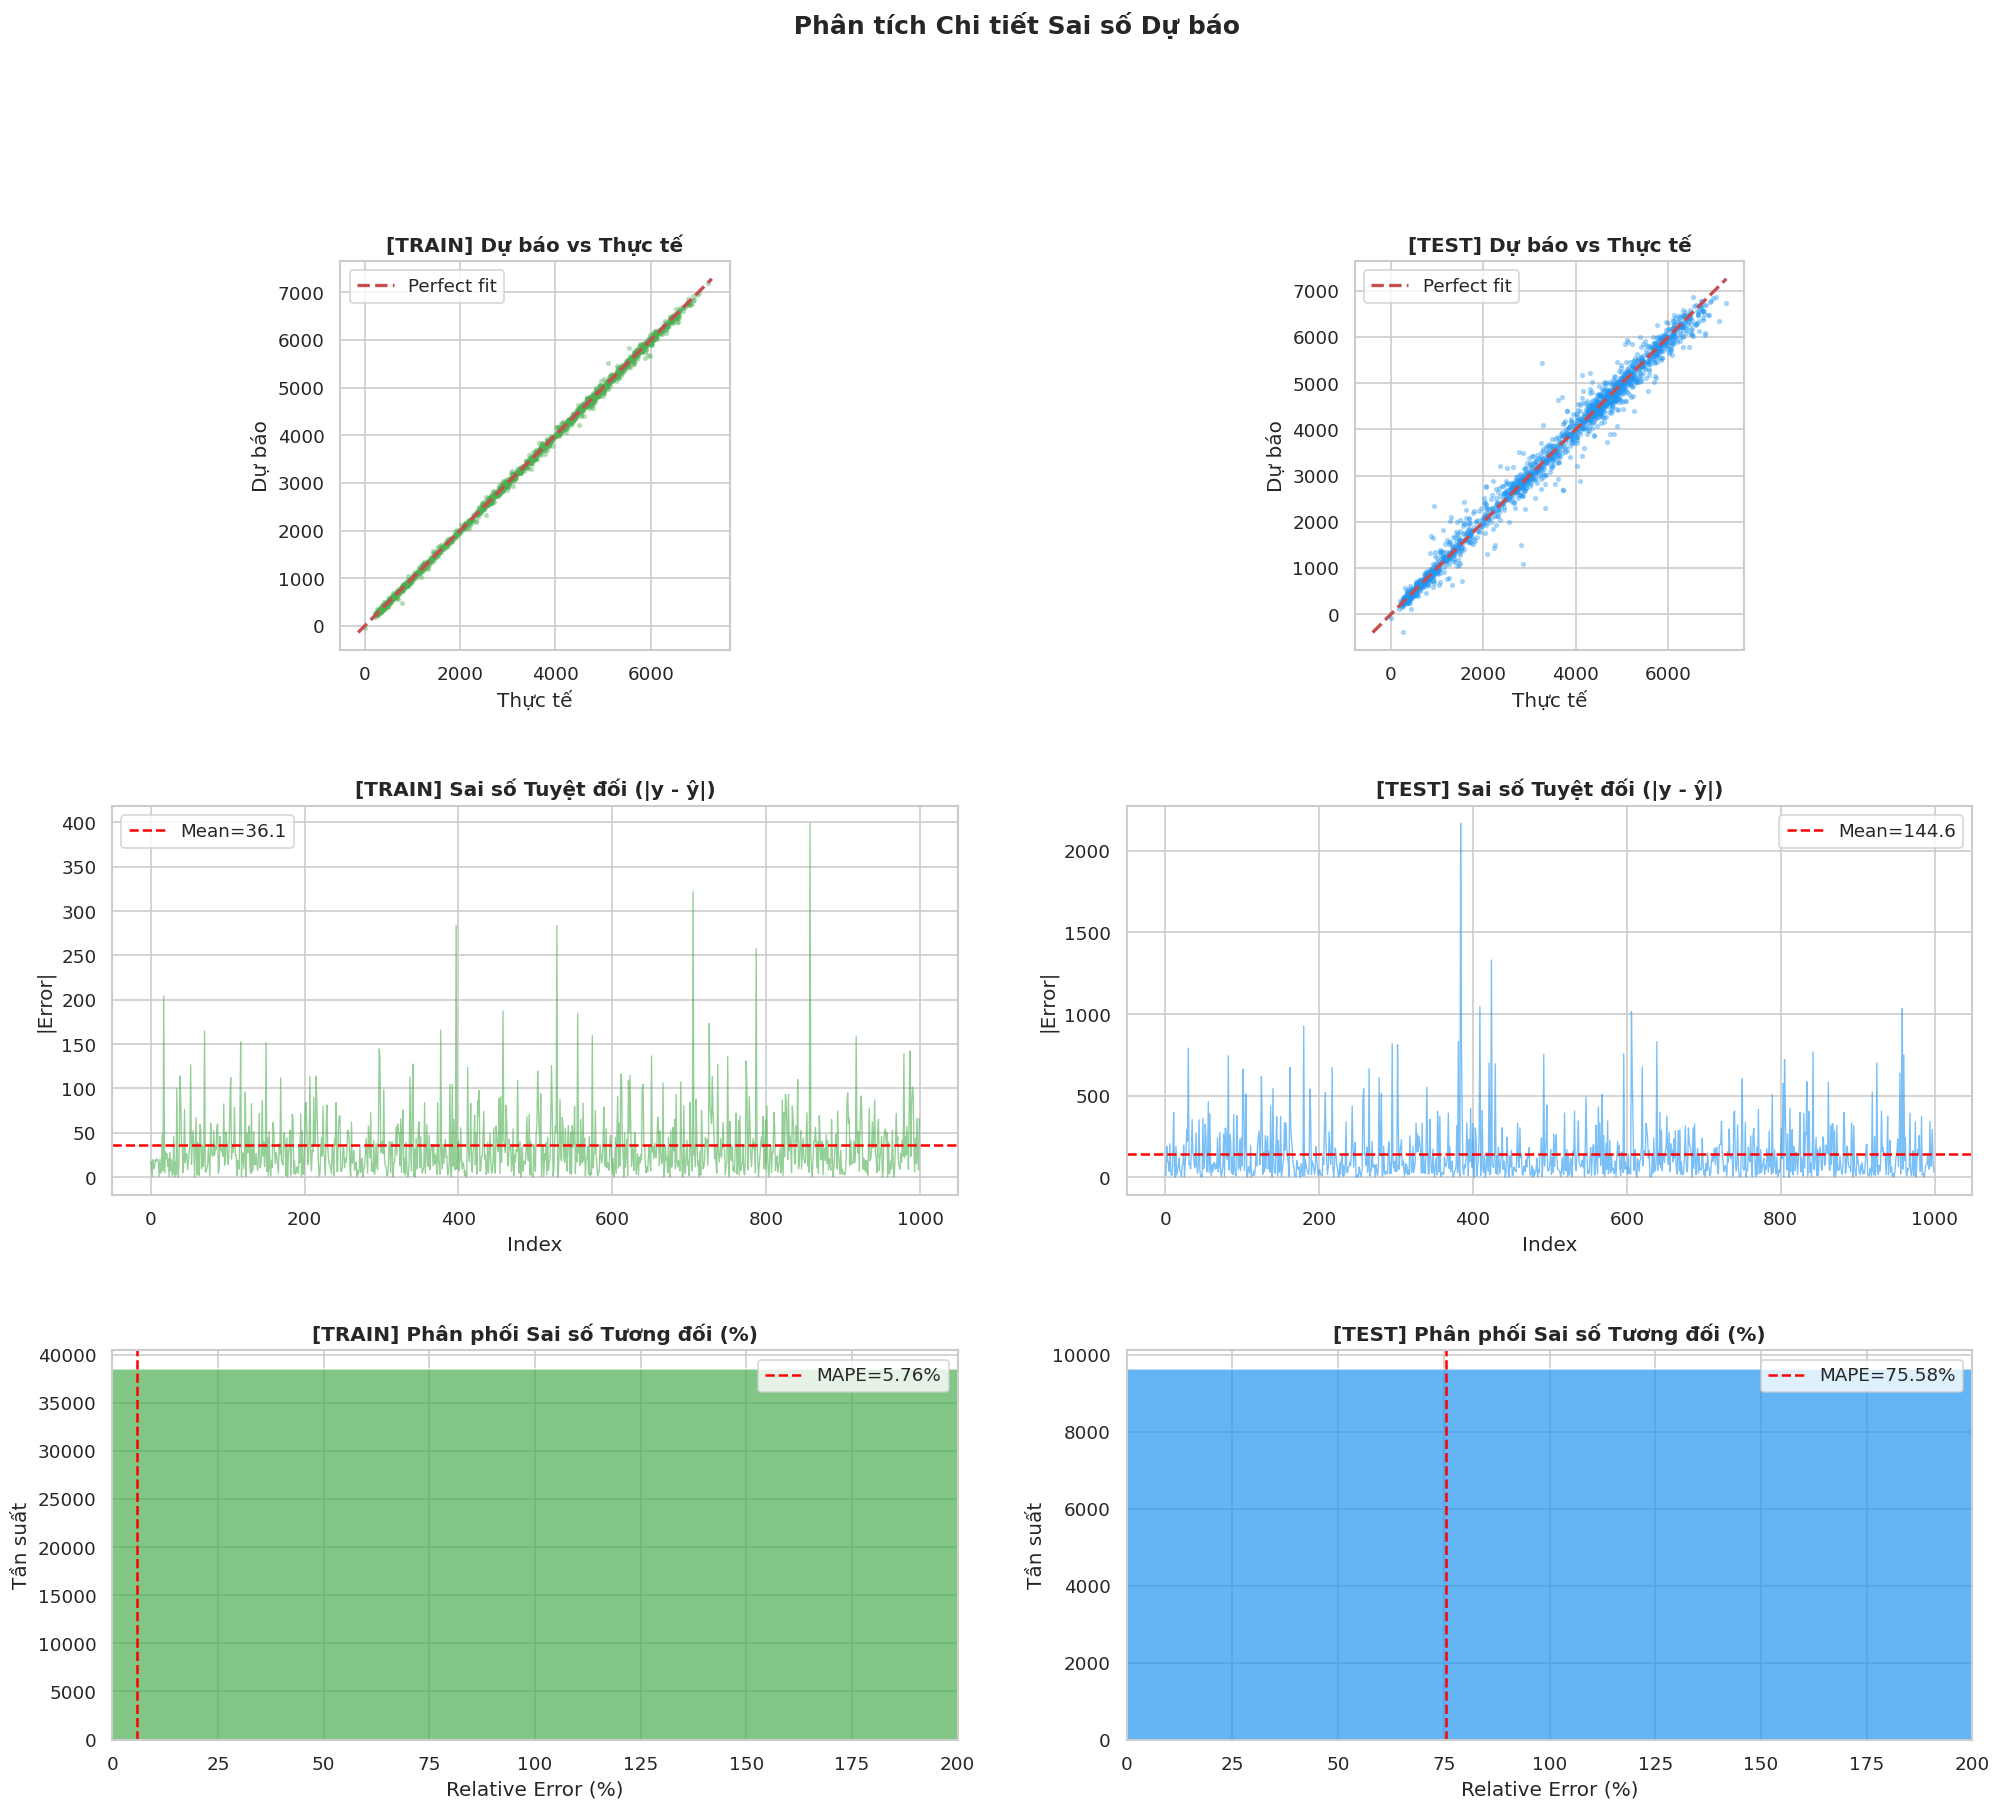

In [78]:
# ============================================================
# BIỂU ĐỒ DỰ BÁO & SAI SỐ TRÊN TRAIN & TEST
# ============================================================
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4)

sets = [
    ('TRAIN', y_train, y_pred_train, '#4CAF50', 0),
    ('TEST',  y_test,  y_pred_test,  '#2196F3', 1),
]

for label, y_true, y_pred, color, col in sets:
    residuals = y_true - y_pred
    abs_err   = np.abs(residuals)
    rel_err   = np.abs(residuals / np.where(y_true != 0, y_true, 1)) * 100

    # 1. Predicted vs Actual
    ax1 = fig.add_subplot(gs[0, col])
    ax1.scatter(y_true[:2000], y_pred[:2000], alpha=0.3, s=5, color=color)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax1.plot(lim, lim, 'r--', linewidth=2, label='Perfect fit')
    ax1.set_title(f'[{label}] Dự báo vs Thực tế', fontweight='bold')
    ax1.set_xlabel('Thực tế'); ax1.set_ylabel('Dự báo')
    ax1.legend(); ax1.set_aspect('equal')

    # 2. Sai số tuyệt đối
    ax2 = fig.add_subplot(gs[1, col])
    ax2.plot(abs_err[:1000], color=color, alpha=0.6, linewidth=0.8)
    ax2.axhline(abs_err.mean(), color='red', linestyle='--', label=f'Mean={abs_err.mean():.1f}')
    ax2.set_title(f'[{label}] Sai số Tuyệt đối (|y - ŷ|)', fontweight='bold')
    ax2.set_xlabel('Index'); ax2.set_ylabel('|Error|')
    ax2.legend()

    # 3. Sai số tương đối (%)
    ax3 = fig.add_subplot(gs[2, col])
    ax3.hist(rel_err, bins=60, color=color, alpha=0.7, edgecolor='white')
    ax3.axvline(rel_err.mean(), color='red', linestyle='--', label=f'MAPE={rel_err.mean():.2f}%')
    ax3.set_title(f'[{label}] Phân phối Sai số Tương đối (%)', fontweight='bold')
    ax3.set_xlabel('Relative Error (%)'); ax3.set_ylabel('Tần suất')
    ax3.set_xlim(0, 200)
    ax3.legend()

plt.suptitle(' Phân tích Chi tiết Sai số Dự báo', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_prediction_error.png', bbox_inches='tight', dpi=150)
plt.show()

## 4.10 Monte Carlo Simulation (100 lần)

 Chạy Monte Carlo Simulation (100 lần)...
  Lần  20: R²=0.9844 | RMSE=247.5
  Lần  40: R²=0.9840 | RMSE=252.0
  Lần  60: R²=0.9837 | RMSE=252.8
  Lần  80: R²=0.9838 | RMSE=253.9
  Lần 100: R²=0.9839 | RMSE=250.6

 KẾT QUẢ MONTE CARLO (100 lần):
  R²: mean=0.9837 | std=0.0008 | min=0.9815 | max=0.9855 | 95% CI=[0.9821, 0.9852]
  RMSE: mean=253.4284 | std=5.7750 | min=238.2876 | max=269.3521 | 95% CI=[241.7945, 264.2892]
  MAE: mean=154.0605 | std=2.1534 | min=149.4910 | max=160.2000 | 95% CI=[149.7608, 158.3798]
  MAPE%: mean=30.3958 | std=18.4464 | min=8.7828 | max=89.4951 | 95% CI=[9.3856, 74.0185]


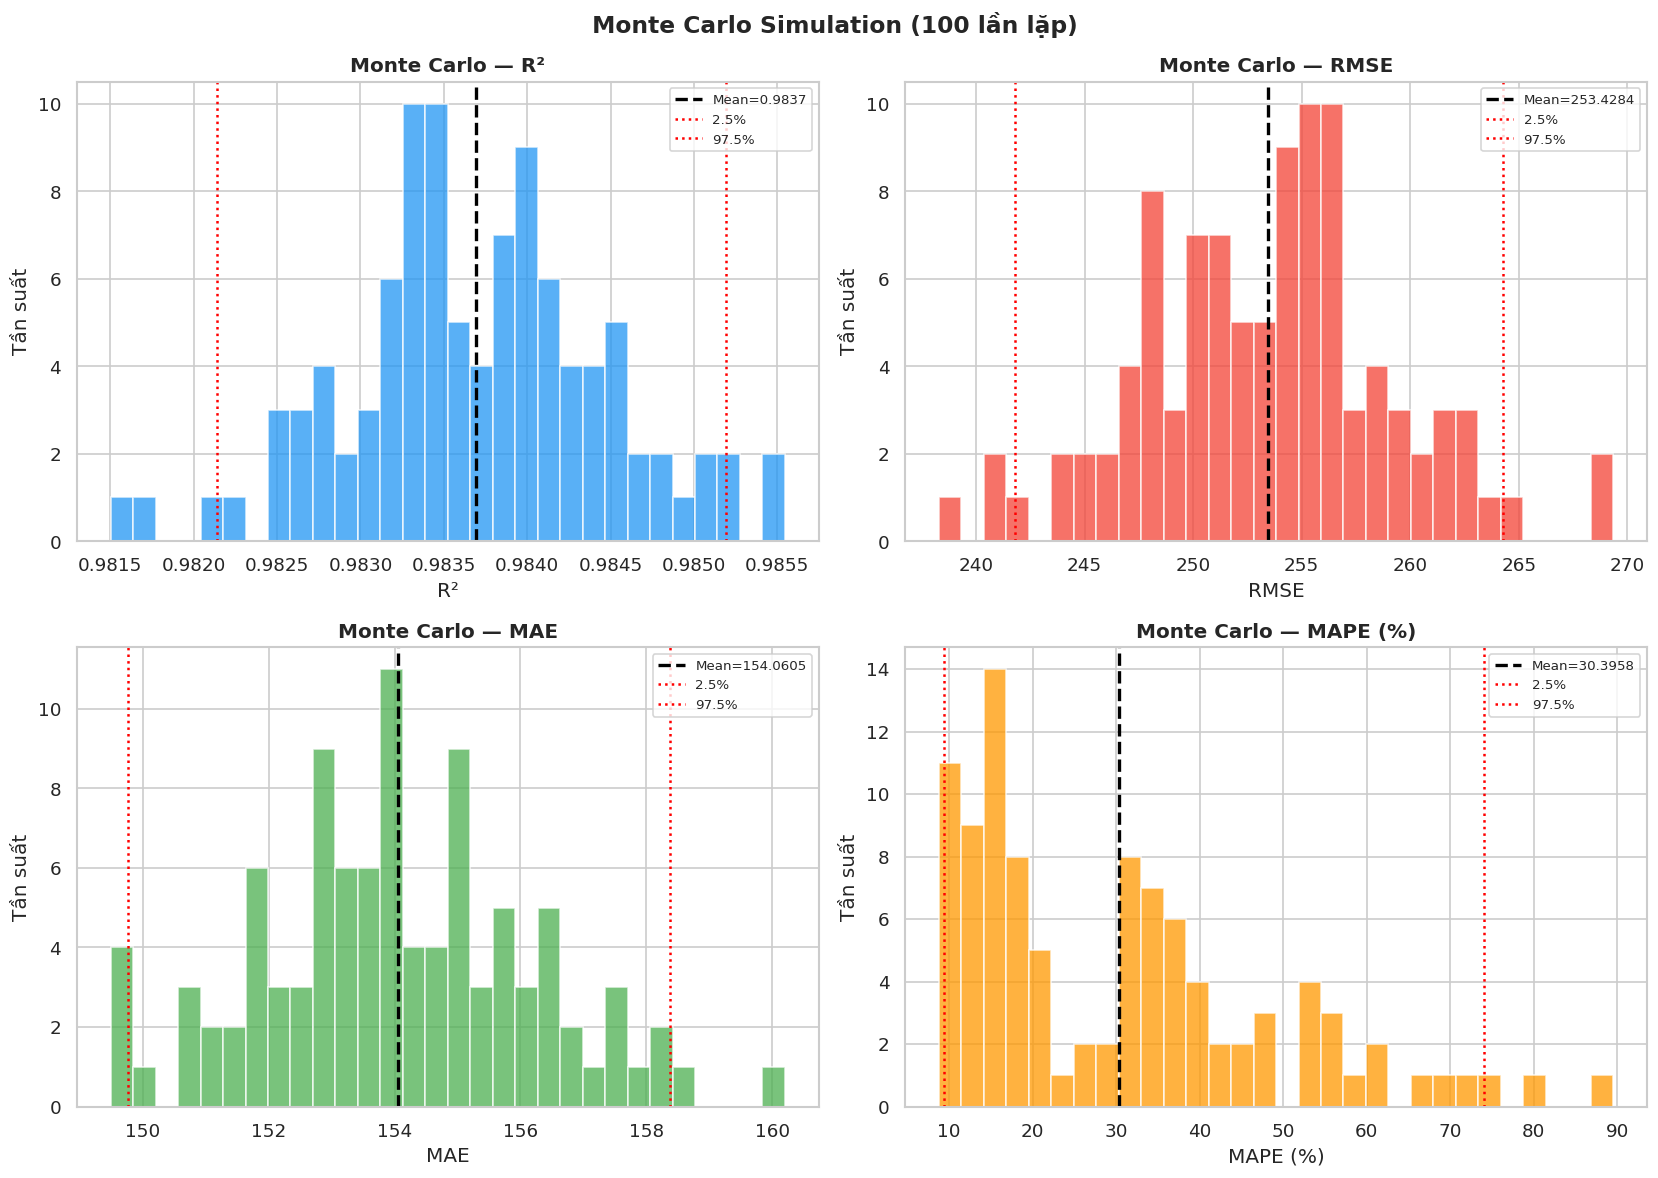

In [79]:
# ============================================================
# MONTE CARLO — 100 LẦN CHẠY VỚI RANDOM SEED KHÁC NHAU
# ============================================================
print(" Chạy Monte Carlo Simulation (100 lần)...")
N_MC = 100
mc_r2, mc_rmse, mc_mae, mc_mape = [], [], [], []

for seed in range(N_MC):
    Xmc_tr, Xmc_te, ymc_tr, ymc_te = train_test_split(
        X_tune, y_train, test_size=0.2, random_state=seed
    )
    mc_model = clone(final_model)
    mc_model.fit(Xmc_tr, ymc_tr)
    ymc_pred = mc_model.predict(Xmc_te)

    mc_r2.append(r2_score(ymc_te, ymc_pred))
    mc_rmse.append(np.sqrt(mean_squared_error(ymc_te, ymc_pred)))
    mc_mae.append(mean_absolute_error(ymc_te, ymc_pred))
    mc_mape.append(mape(ymc_te, ymc_pred))

    if (seed + 1) % 20 == 0:
        print(f"  Lần {seed+1:3d}: R²={mc_r2[-1]:.4f} | RMSE={mc_rmse[-1]:.1f}")

print(f"\n KẾT QUẢ MONTE CARLO ({N_MC} lần):")
for name_m, arr in [('R²', mc_r2), ('RMSE', mc_rmse), ('MAE', mc_mae), ('MAPE%', mc_mape)]:
    print(f"  {name_m}: mean={np.mean(arr):.4f} | std={np.std(arr):.4f} | "
          f"min={np.min(arr):.4f} | max={np.max(arr):.4f} | "
          f"95% CI=[{np.percentile(arr,2.5):.4f}, {np.percentile(arr,97.5):.4f}]")

# Vẽ biểu đồ Monte Carlo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
mc_data  = [mc_r2, mc_rmse, mc_mae, mc_mape]
mc_names = ['R²', 'RMSE', 'MAE', 'MAPE (%)']
mc_clrs  = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

for ax, data, name, clr in zip(axes.flat, mc_data, mc_names, mc_clrs):
    ax.hist(data, bins=30, color=clr, alpha=0.75, edgecolor='white')
    ax.axvline(np.mean(data), color='black', linestyle='--', linewidth=2,
               label=f'Mean={np.mean(data):.4f}')
    ax.axvline(np.percentile(data, 2.5),  color='red', linestyle=':', label='2.5%')
    ax.axvline(np.percentile(data, 97.5), color='red', linestyle=':', label='97.5%')
    ax.set_title(f'Monte Carlo — {name}', fontweight='bold')
    ax.set_xlabel(name); ax.set_ylabel('Tần suất')
    ax.legend(fontsize=8)

plt.suptitle(f' Monte Carlo Simulation ({N_MC} lần lặp)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_monte_carlo.png', bbox_inches='tight', dpi=150)
plt.show()

## 4.11 SHAP — Giải thích Mô hình

 Tính SHAP values...


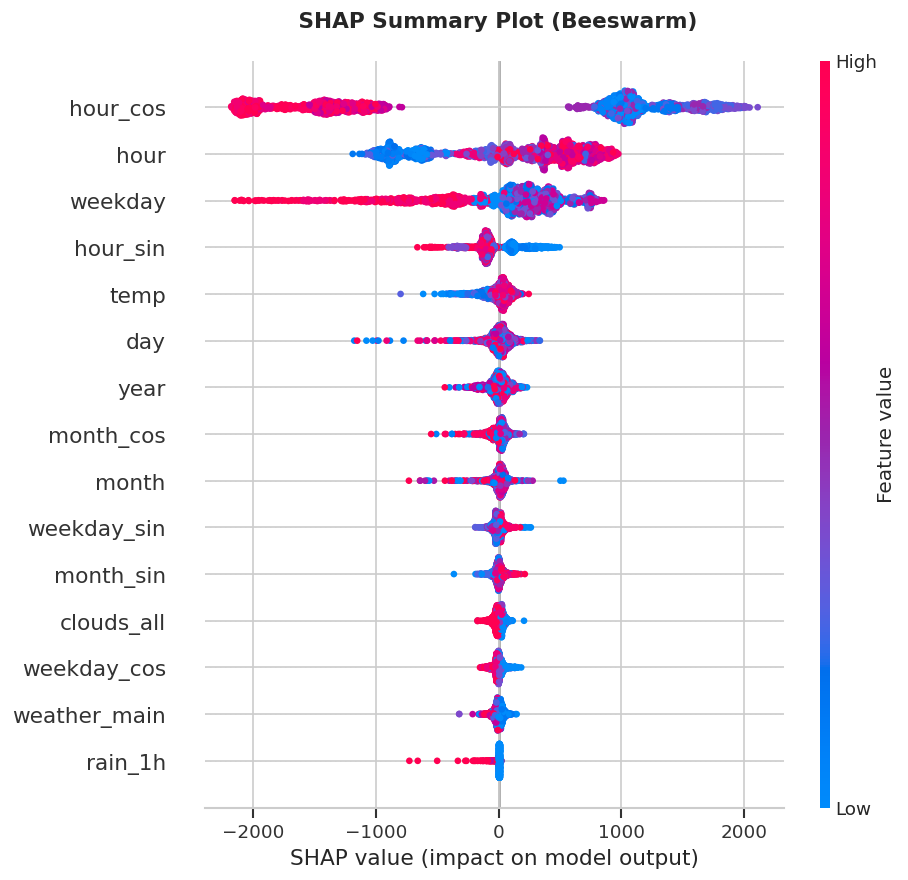

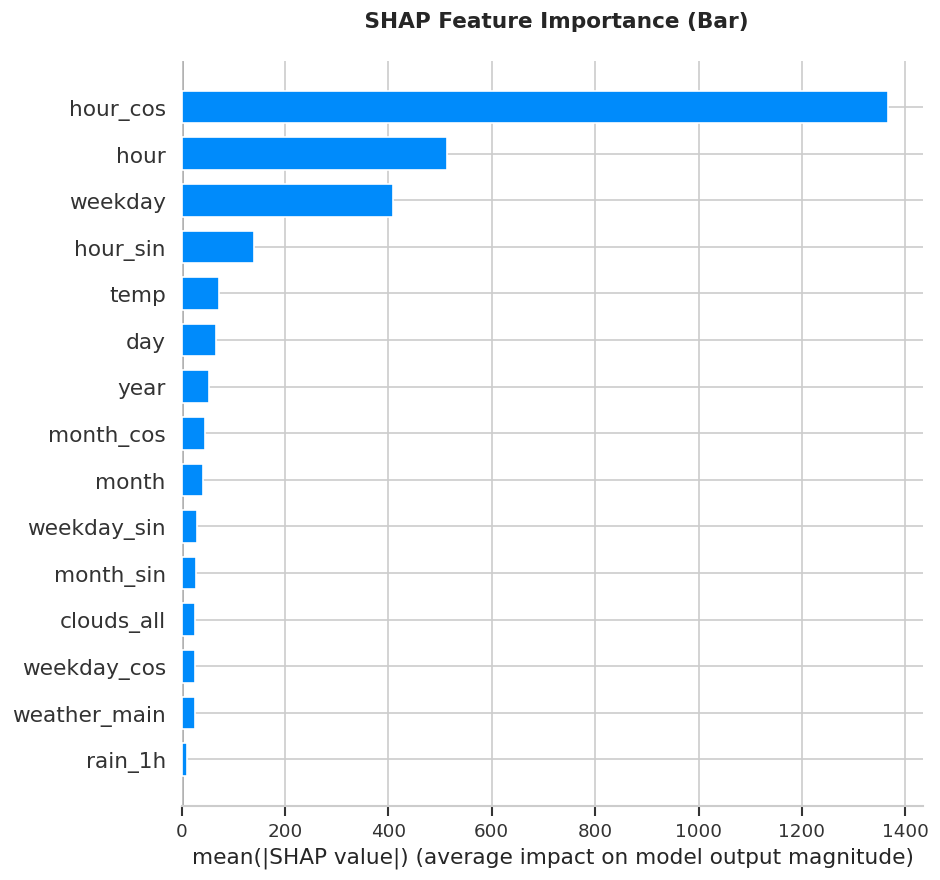

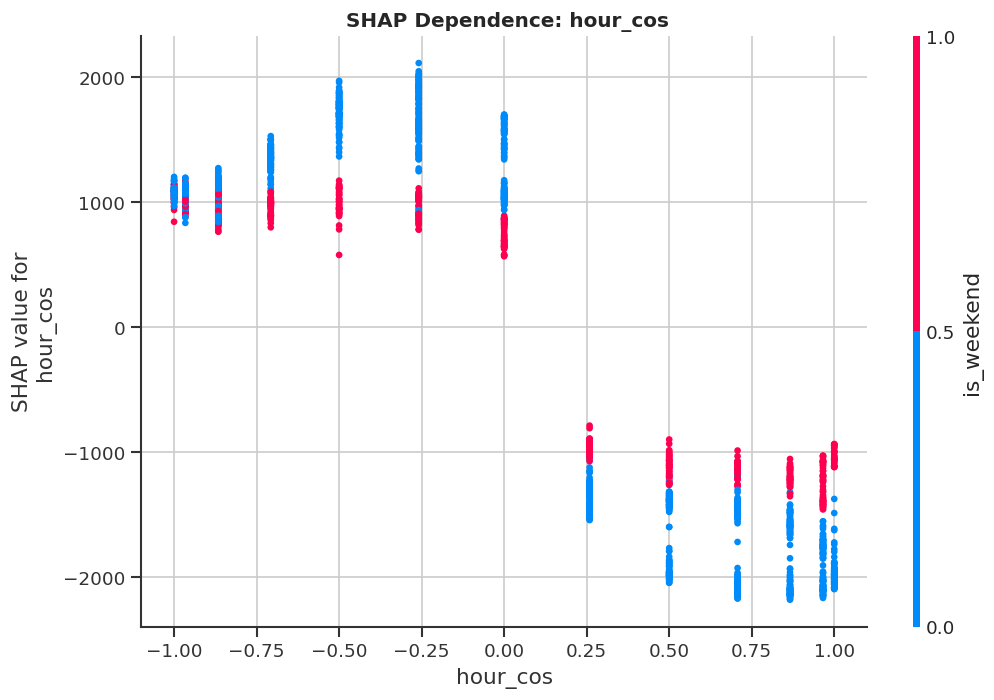

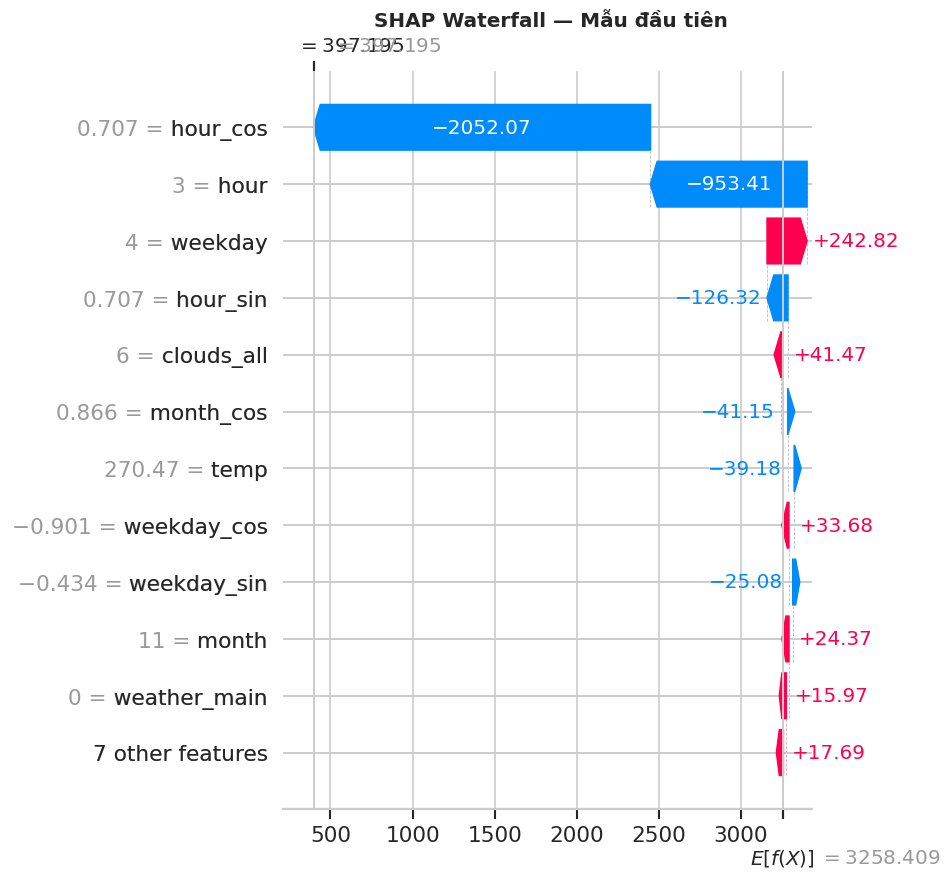


 Top 5 đặc trưng quan trọng nhất (SHAP):
 Feature  SHAP_mean_abs
hour_cos    1366.548462
    hour     512.797913
 weekday     408.005096
hour_sin     139.770767
    temp      72.712357


In [80]:
# ============================================================
# SHAP VALUES
# ============================================================
print(" Tính SHAP values...")
shap.initjs()

# Lấy mẫu nhỏ để tính nhanh
N_SHAP = min(2000, len(X_tune_test))
X_shap_sample = X_tune_test[:N_SHAP]

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap_sample)

feature_names = FEATURE_COLS

# 1. Summary Plot (Beeswarm)
fig1, ax1 = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, feature_names=feature_names,
                  show=False, max_display=15)
plt.title(' SHAP Summary Plot (Beeswarm)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

# 2. Bar Plot (Feature Importance)
fig2, ax2 = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap_sample, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=15)
plt.title(' SHAP Feature Importance (Bar)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()

# 3. Dependence Plot — feature quan trọng nhất
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = feature_names[top_feature_idx]

fig3, ax3 = plt.subplots(figsize=(9, 6))
shap.dependence_plot(top_feature_idx, shap_values, X_shap_sample,
                     feature_names=feature_names, ax=ax3, show=False)
ax3.set_title(f' SHAP Dependence: {top_feature_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_shap_dependence.png', bbox_inches='tight', dpi=150)
plt.show()

# 4. Waterfall (1 mẫu)
shap_exp = shap.Explanation(values=shap_values[0], base_values=explainer.expected_value,
                            data=X_shap_sample[0], feature_names=feature_names)
fig4, ax4 = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(shap_exp, max_display=12, show=False)
plt.title(' SHAP Waterfall — Mẫu đầu tiên', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_shap_waterfall.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n Top 5 đặc trưng quan trọng nhất (SHAP):")
shap_importance = pd.DataFrame({'Feature': feature_names, 'SHAP_mean_abs': mean_abs_shap})
print(shap_importance.sort_values('SHAP_mean_abs', ascending=False).head(5).to_string(index=False))

## 4.12 Partial Dependence Plot (PDP)

 Vẽ PDP cho top 4 features: ['hour_cos', 'hour', 'weekday', 'hour_sin']


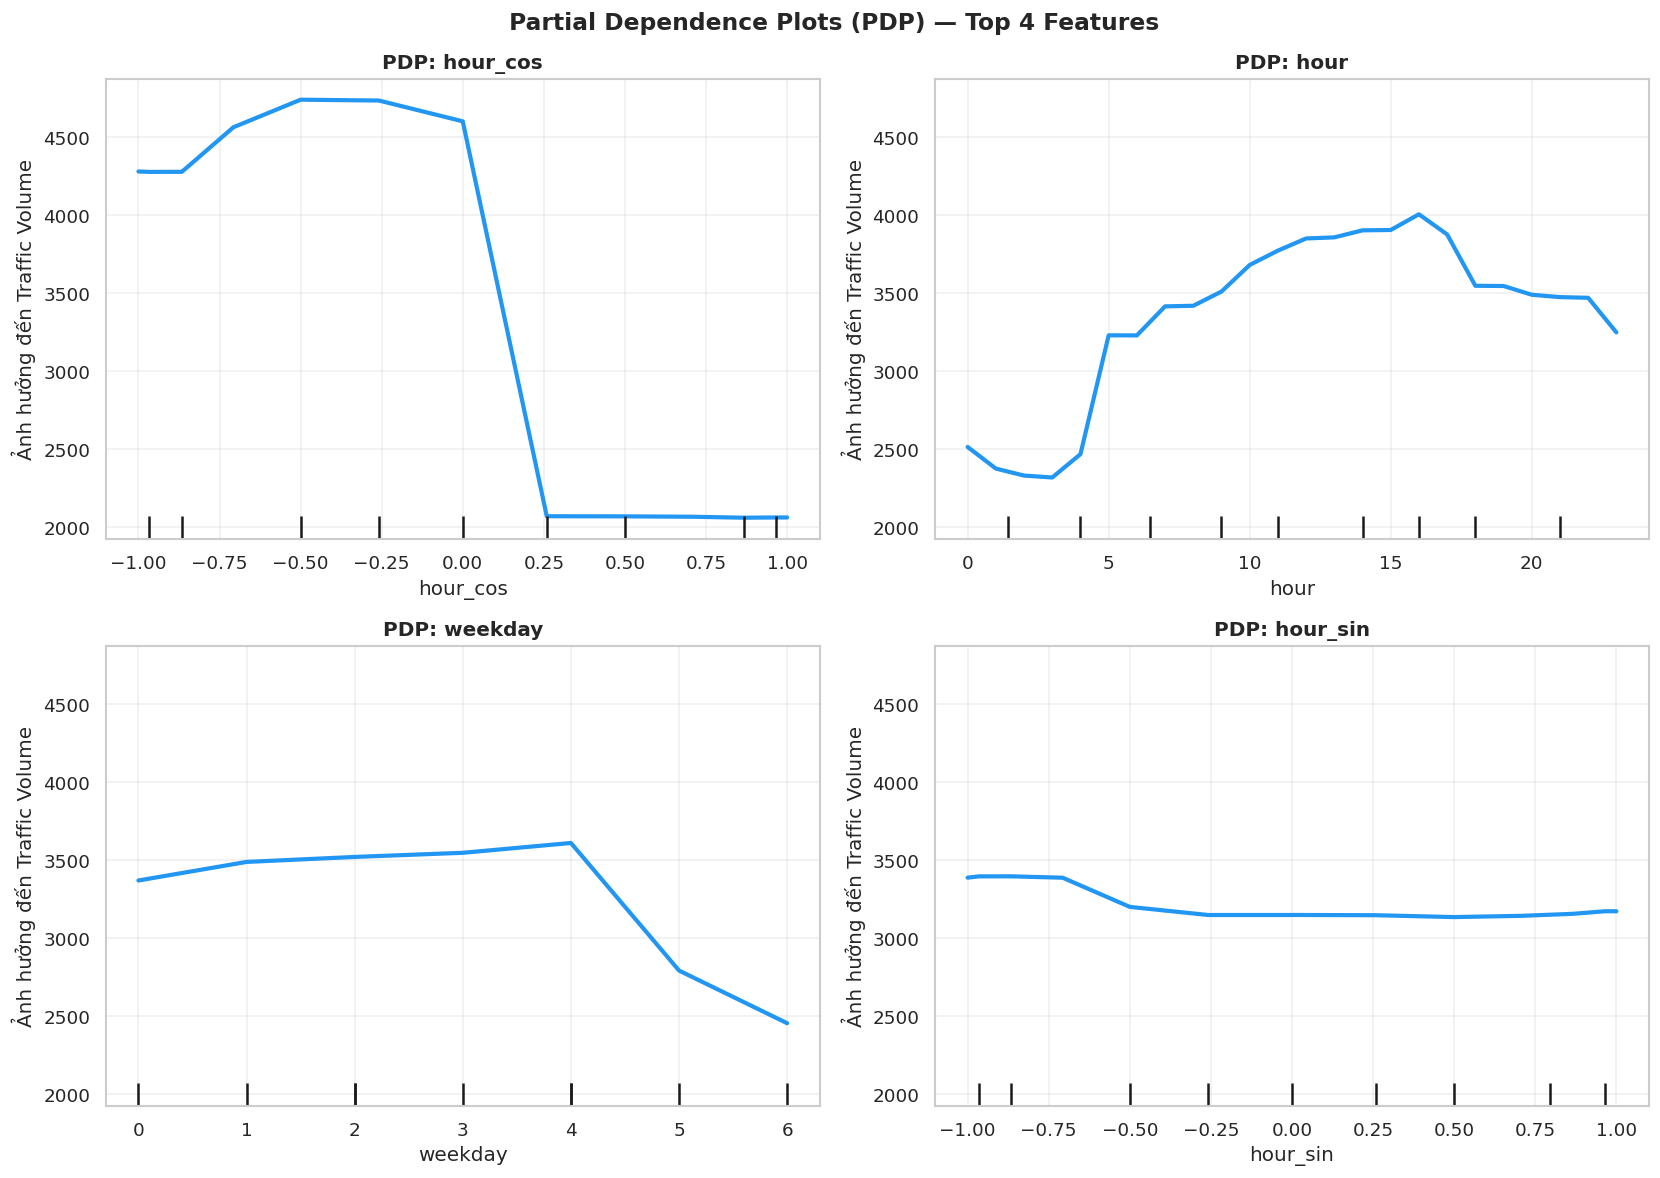

In [81]:
# ============================================================
# PDP — Partial Dependence Plot
# ============================================================
# Chọn top 4 features quan trọng nhất
top4_idx = np.argsort(mean_abs_shap)[-4:][::-1].tolist()
top4_names = [feature_names[i] for i in top4_idx]

print(f" Vẽ PDP cho top 4 features: {top4_names}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    final_model, X_tune_test[:1000], features=top4_idx,
    feature_names=feature_names,
    ax=axes.flat, grid_resolution=50,
    line_kw={'color': '#2196F3', 'linewidth': 2.5}
)
for ax, name in zip(axes.flat, top4_names):
    ax.set_title(f'PDP: {name}', fontweight='bold')
    ax.set_ylabel('Ảnh hưởng đến Traffic Volume')
    ax.grid(True, alpha=0.3)

plt.suptitle(' Partial Dependence Plots (PDP) — Top 4 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_pdp.png', bbox_inches='tight', dpi=150)
plt.show()

## 4.13 LIME — Local Interpretable Model-Agnostic Explanations

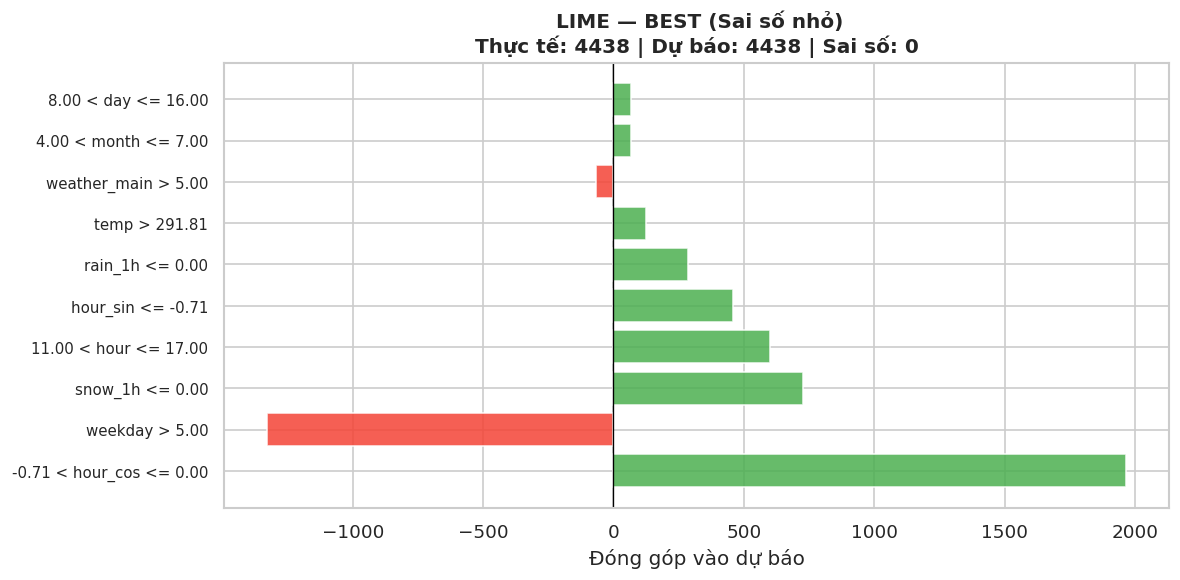

  LIME [BEST (Sai số nhỏ)] đã lưu


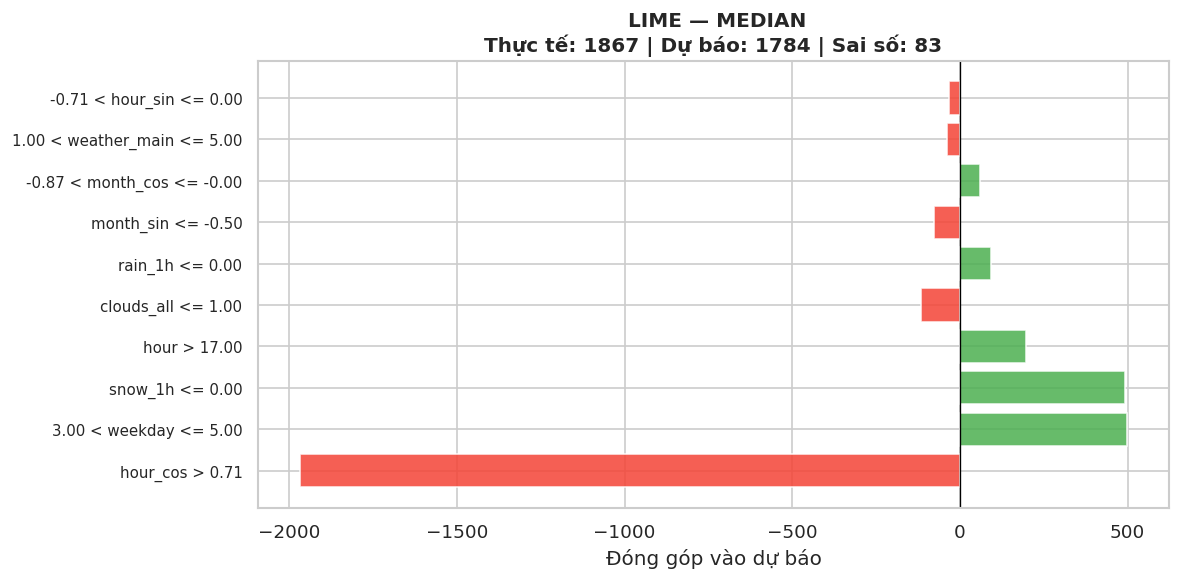

  LIME [MEDIAN] đã lưu


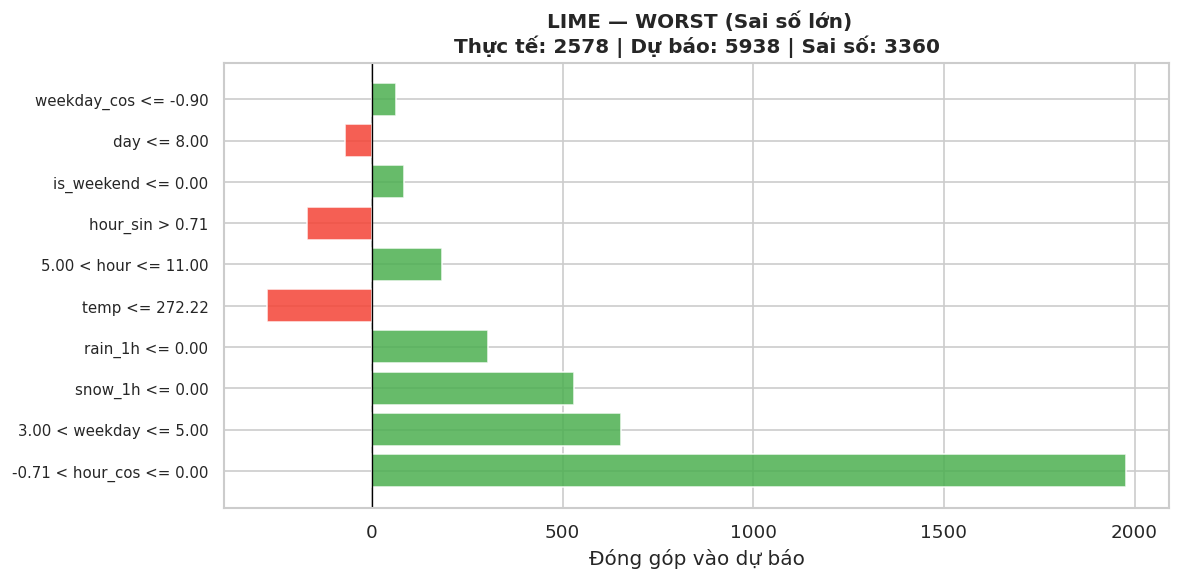

  LIME [WORST (Sai số lớn)] đã lưu


In [82]:
# ============================================================
# LIME EXPLANATION
# ============================================================
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_tune,
    feature_names  = feature_names,
    mode           = 'regression',
    random_state   = 42
)

# Giải thích 3 mẫu: tốt, trung bình, xấu
y_pred_abs_err = np.abs(y_test - y_pred_test)
idx_best   = np.argmin(y_pred_abs_err)           # Sai số nhỏ nhất
idx_median = np.argsort(y_pred_abs_err)[len(y_pred_abs_err)//2]  # Sai số trung bình
idx_worst  = np.argmax(y_pred_abs_err)           # Sai số lớn nhất

for idx, label in [(idx_best, 'BEST (Sai số nhỏ)'), (idx_median, 'MEDIAN'), (idx_worst, 'WORST (Sai số lớn)')]:
    exp = lime_explainer.explain_instance(
        X_tune_test[idx], final_model.predict, num_features=10
    )

    vals  = [x[1] for x in exp.as_list()]
    names = [x[0] for x in exp.as_list()]
    colors = ['#4CAF50' if v > 0 else '#F44336' for v in vals]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(range(len(vals)), vals, color=colors, alpha=0.85)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(
        f' LIME — {label}\n'
        f'Thực tế: {y_test[idx]:.0f} | Dự báo: {y_pred_test[idx]:.0f} | '
        f'Sai số: {y_pred_abs_err[idx]:.0f}',
        fontweight='bold'
    )
    ax.set_xlabel('Đóng góp vào dự báo')
    plt.tight_layout()
    save_name = label.split(' ')[0].lower()
    plt.savefig(f'/content/drive/MyDrive/MachineLearning/result_pics/fig_lime_{save_name}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"  LIME [{label}] đã lưu")

---
# PHẦN 5: NHẬN XÉT TỔNG HỢP

In [84]:
# ============================================================
# BẢNG SO SÁNH TRƯỚC & SAU TINH CHỈNH
# ============================================================
baseline_best = df_results.sort_values('R²_test', ascending=False).iloc[0]
final_res = evaluate_model(final_model, X_tune, y_train, X_tune_test, y_test, 'Mô hình Tinh chỉnh')

print("=" * 75)
print(" BẢNG SO SÁNH: TRƯỚC & SAU KHI ÁP DỤNG CHIẾN LƯỢC TINH CHỈNH")
print("=" * 75)

compare_tbl = pd.DataFrame([
    {
        'Giai đoạn'   : ' Trước tinh chỉnh (Baseline)',
        'Mô hình'     : baseline_best['Model'],
        'R²_train'    : baseline_best['R²_train'],
        'R²_test'     : baseline_best['R²_test'],
        'RMSE_test'   : baseline_best['RMSE_test'],
        'MAE_test'    : baseline_best['MAE_test'],
        'MAPE_test(%)'  : baseline_best['MAPE_test'],
    },
    {
        'Giai đoạn'   : 'Sau tinh chỉnh (Tuned)',
        'Mô hình'     : f'{BEST_MODEL_NAME} (Tuned)',
        'R²_train'    : final_res['R²_train'],
        'R²_test'     : final_res['R²_test'],
        'RMSE_test'   : final_res['RMSE_test'],
        'MAE_test'    : final_res['MAE_test'],
        'MAPE_test(%)': final_res['MAPE_test'],
    }
])
print(compare_tbl.to_string(index=False, float_format='{:.4f}'.format))

delta_r2   = final_res['R²_test']   - baseline_best['R²_test']
delta_rmse = final_res['RMSE_test'] - baseline_best['RMSE_test']
delta_mae  = final_res['MAE_test']  - baseline_best['MAE_test']
delta_mape = final_res['MAPE_test'] - baseline_best['MAPE_test']

print(f"\n CẢI THIỆN:")
print(f"  ΔR²   = {delta_r2:+.4f} ")
print(f"  ΔRMSE = {delta_rmse:+.2f} ")
print(f"  ΔMAE  = {delta_mae:+.2f} ")
print(f"  ΔMAPE = {delta_mape:+.2f}% ")


 BẢNG SO SÁNH: TRƯỚC & SAU KHI ÁP DỤNG CHIẾN LƯỢC TINH CHỈNH
                   Giai đoạn             Mô hình  R²_train  R²_test  RMSE_test  MAE_test  MAPE_test(%)
 Trước tinh chỉnh (Baseline)         07. XGBoost    0.9821   0.9751   314.1882  197.8317      100.4421
      Sau tinh chỉnh (Tuned) 07. XGBoost (Tuned)    0.9993   0.9852   242.2676  144.5938       75.5836

 CẢI THIỆN:
  ΔR²   = +0.0101 
  ΔRMSE = -71.92 
  ΔMAE  = -53.24 
  ΔMAPE = -24.86% 


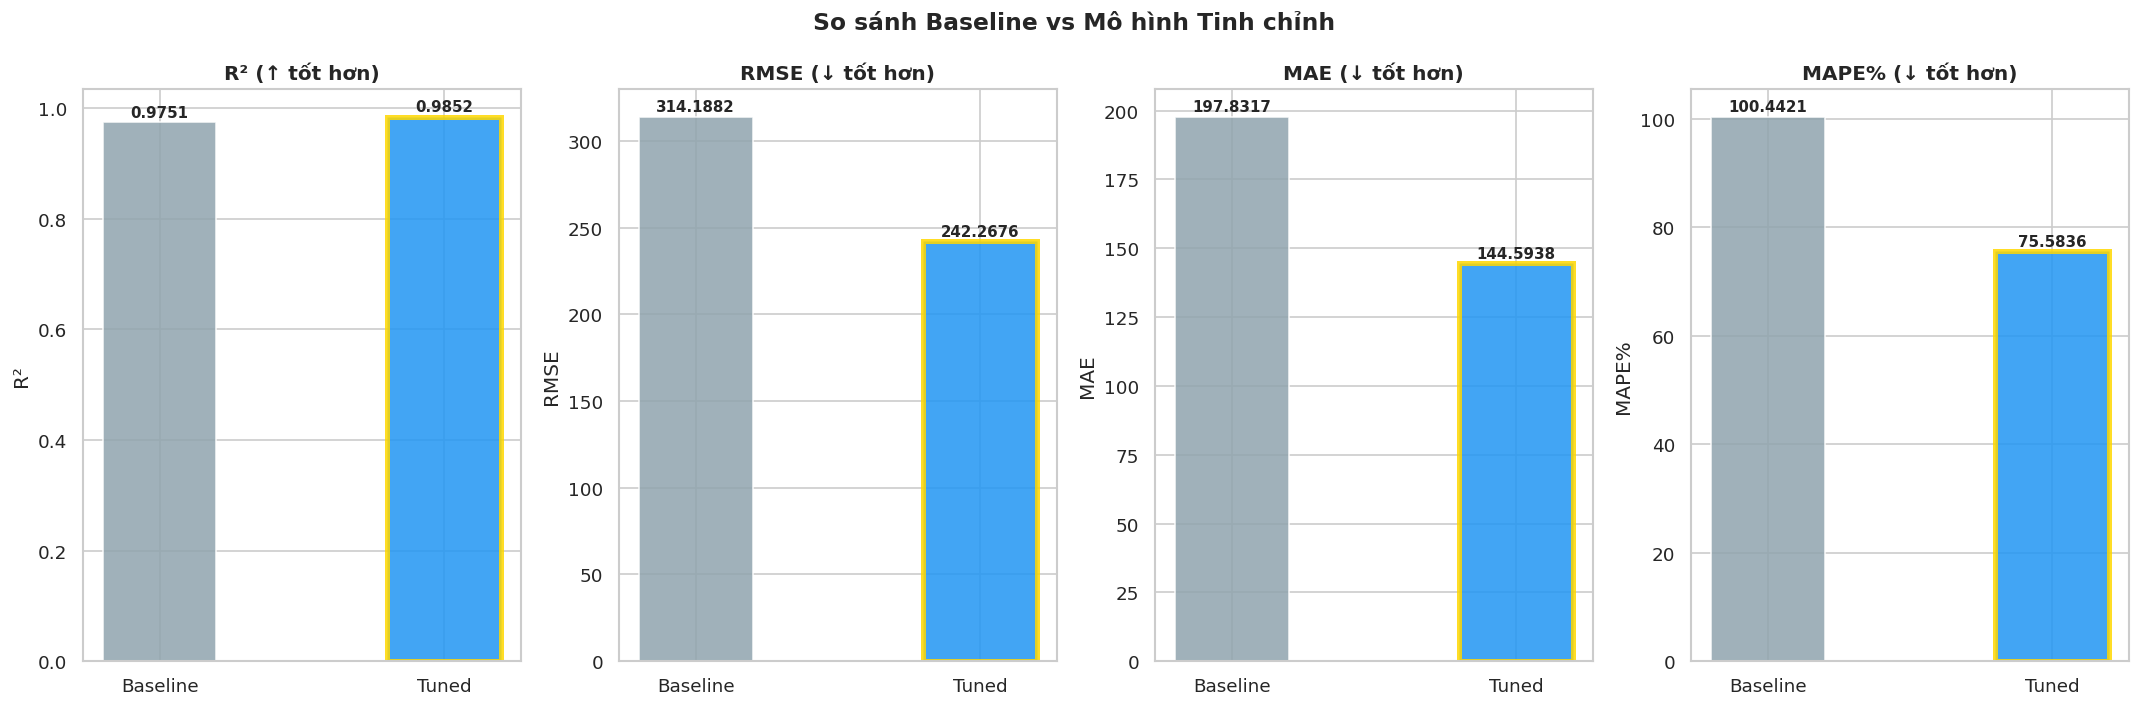


 Tất cả biểu đồ đã được lưu vào: /content/drive/MyDrive/MachineLearning/result_pics/
    fig_baseline_comparison.png
    fig_before_after.png
    fig_correlation.png
    fig_cv_test.png
    fig_lime_best.png
    fig_lime_median.png
    fig_lime_worst.png
    fig_monte_carlo.png
    fig_numerical.png
    fig_pdp.png
    fig_prediction_error.png
    fig_shap_bar.png
    fig_shap_beeswarm.png
    fig_shap_dependence.png
    fig_shap_waterfall.png
    fig_target_dist.png
    fig_time_analysis.png
    fig_train_cv_test.png


In [86]:
# ============================================================
# BIỂU ĐỒ TỔNG HỢP SO SÁNH TRƯỚC & SAU
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

before_vals = [baseline_best['R²_test'],  baseline_best['RMSE_test'],
               baseline_best['MAE_test'],  baseline_best['MAPE_test']]
after_vals  = [final_res['R²_test'],  final_res['RMSE_test'],
               final_res['MAE_test'],  final_res['MAPE_test']]
metric_names_cmp = ['R² (↑ tốt hơn)', 'RMSE (↓ tốt hơn)', 'MAE (↓ tốt hơn)', 'MAPE% (↓ tốt hơn)']

for ax, m_name, bv, av in zip(axes, metric_names_cmp, before_vals, after_vals):
    bars = ax.bar(['Baseline', 'Tuned'], [bv, av], color=['#90A4AE', '#2196F3'], alpha=0.85, width=0.4)
    for bar, val in zip(bars, [bv, av]):
        ax.text(bar.get_x() + bar.get_width()/2, val + max(bv, av)*0.01,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)
    ax.set_title(m_name, fontweight='bold')
    ax.set_ylabel(m_name.split(' ')[0])
    # Highlight cột tốt hơn
    better_idx = 1 if (
        (av > bv and '↑' in m_name) or (av < bv and '↓' in m_name)
    ) else 0
    bars[better_idx].set_edgecolor('gold')
    bars[better_idx].set_linewidth(3)

plt.suptitle(' So sánh Baseline vs Mô hình Tinh chỉnh', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MachineLearning/result_pics/fig_before_after.png', bbox_inches='tight', dpi=150)
plt.show()



print("\n Tất cả biểu đồ đã được lưu vào: /content/drive/MyDrive/MachineLearning/result_pics/")

import os
saved_files = [f for f in os.listdir('/content/drive/MyDrive/MachineLearning/result_pics/') if f.endswith('.png')]
for f in sorted(saved_files):
    print(f"    {f}")